# Hub model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

..........
Time elapsed, in minutes: 3.48
Done calculating. Now plotting it all, which may take even longer!
Time elapsed, in minutes: 0.28


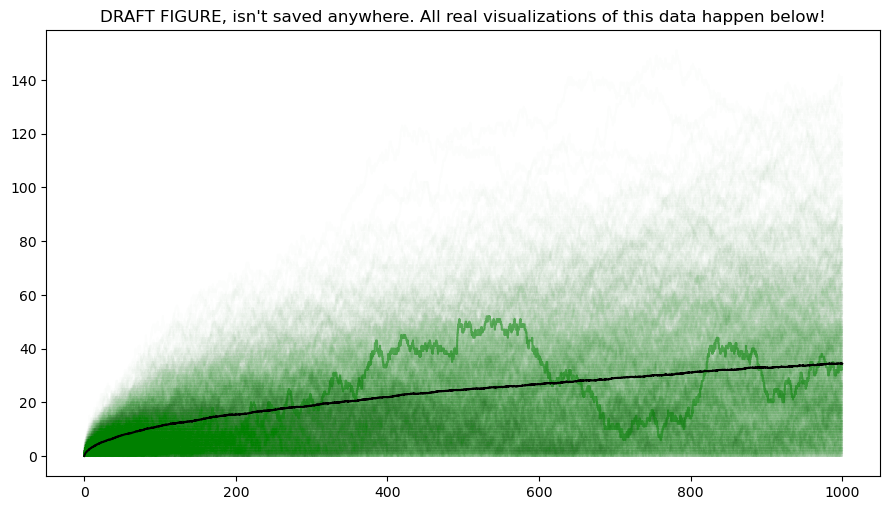

In [2]:
# Basic model
t_max = 100000 # This will take a while
p0 = 0.01
n_cars = 1000 # At t_max of 10000 it's enough to have 100 cars, but at 100 000 we start to hit upper limit.
np.random.seed(3)

out = None
tic = time.time()
for i in range(1000):
    if i % 100 == 0:
        print('.', end='')
    demand_to = (np.random.uniform(size=(t_max)) < p0)*1
    demand_from = (np.random.uniform(size=(t_max)) < p0)*1

    cars = np.cumsum(demand_to - demand_from)
    cars = cars - np.minimum.accumulate(cars.clip(None,0))
    cars = cars - np.maximum.accumulate(cars.clip(n_cars,None)) + n_cars
    if out is None:
        out = cars[:, np.newaxis]
    else:
        out = np.concatenate((out, cars[:, np.newaxis]), axis=1)

print()
toc = time.time()
print(f"Time elapsed, in minutes: {(toc - tic)/60:.2f}")
print("Done calculating. Now plotting it all, which may take even longer!")
    
plt.figure(figsize=(9,5))
plt.plot(np.arange(t_max)*p0, out, 'g-', alpha=0.01);
plt.plot(np.arange(t_max)*p0, out[:,0], 'g-', alpha=0.5);
plt.plot(np.arange(t_max)*p0, out.mean(axis=1), 'k-');
plt.tight_layout()
plt.title("DRAFT FIGURE, isn't saved anywhere. All real visualizations of this data happen below!")
plt.show()
tac = time.time()
print(f"Time elapsed, in minutes: {(tac - toc)/60:.2f}")

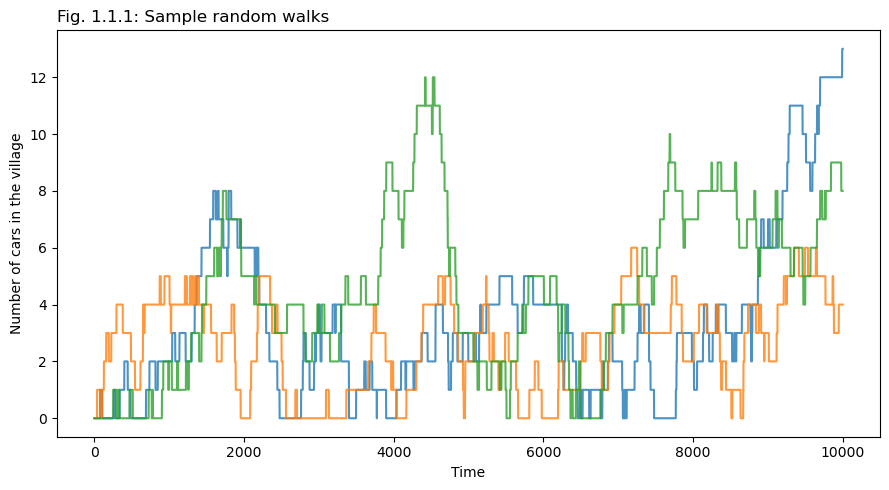

In [3]:
plt.figure(figsize=(9,5))
plt.plot(out[:10000,[1,5,8]], '-', alpha=0.8);
plt.xlabel('Time')
plt.ylabel("Number of cars in the village")
plt.title("Fig. 1.1.1: Sample random walks", loc='left')

plt.tight_layout()
plt.savefig("../figures/01simple_01village_01sample_walks.svg", dpi=300)  # Only 3 tracks so we can use a svg

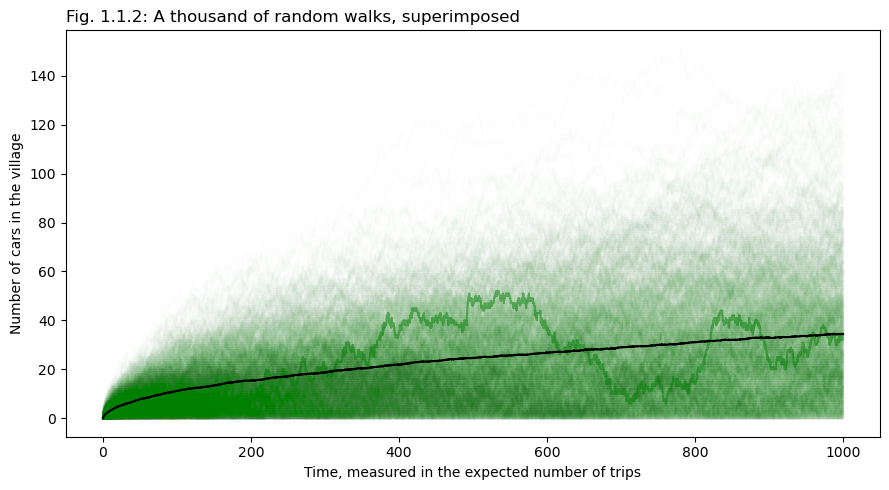

In [4]:
plt.figure(figsize=(9,5))
plt.plot(np.arange(t_max)*p0, out, 'g-', alpha=0.01);
plt.plot(np.arange(t_max)*p0, out[:,0], 'g-', alpha=0.5); # Sample curve
plt.plot(np.arange(t_max)*p0, out.mean(axis=1), 'k-');
plt.tight_layout()

plt.xlabel('Time, measured in the expected number of trips')
plt.ylabel("Number of cars in the village")
plt.title("Fig. 1.1.2: A thousand of random walks, superimposed", loc='left')

plt.tight_layout()
plt.savefig("../figures/01simple_01village_02all_walks.png", dpi=300) # Png as vector gets too heavy here

In [5]:
# Calculate N rentals till a certain average N cars
y = out.mean(axis=1)
rentals_to_value = None
for i in [2, 5, 10, 15, 20, 25, 30]:
    position = np.round(np.where((y[1:]>i) & (y[:-1]<i))[0][0]*p0).astype(int)
    if rentals_to_value is None:
        rentals_to_value = pd.DataFrame({"CARS_IN_HUB":[i], "RENTALS_TO_WAIT": [position]})
    else:
        rentals_to_value.loc[len(rentals_to_value)] = [i, position]

rentals_to_value

,CARS_IN_HUB,RENTALS_TO_WAIT
0,2,5
1,5,22
2,10,80
3,15,182
4,20,336
5,25,511
6,30,750


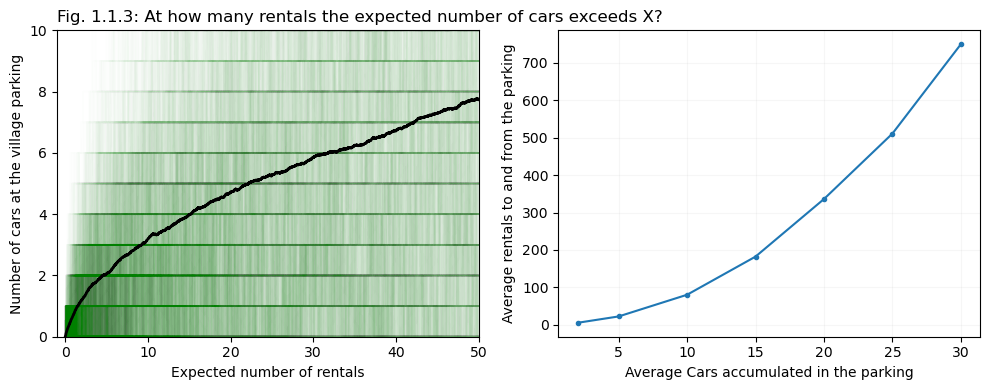

In [6]:
# Zoom-in curve + rentals-to-trap curve
plt.figure(figsize=(10,4))
plt.subplot(121)
n_points = 5000
plt.plot(np.arange(n_points)*p0, out[:n_points,:], 'g-', alpha=0.007);
plt.plot(np.arange(n_points)*p0, out[:n_points,:].mean(axis=1), 'k-', linewidth=2);
plt.ylim(0, 10)
plt.xlim(-1, 50)

plt.xlabel('Expected number of rentals')
plt.ylabel("Number of cars at the village parking")
plt.title("Fig. 1.1.3: At how many rentals the expected number of cars exceeds X?", loc='left')

plt.subplot(122)
plt.plot(rentals_to_value.CARS_IN_HUB, rentals_to_value.RENTALS_TO_WAIT, '.-')
plt.xlabel('Average Cars accumulated in the parking')
plt.ylabel("Average rentals to and from the parking")
plt.grid(alpha=0.1)

plt.tight_layout()
plt.savefig("../figures/01simple_01village_03curve_beginning.png", dpi=300) # Png as vector gets too heavy here

# Relocations

In [36]:
# Relocation counter
t_max = 10000
p0 = 0.01
n_cars = 10
n_experiments = 500

out = None
relos = None
tic = time.time()
for i in range(n_experiments):
    demand_to = (np.random.uniform(size=(t_max)) < p0)*1
    demand_from = (np.random.uniform(size=(t_max)) < p0)*1

    cars = np.cumsum(demand_to - demand_from)
    cars = cars - np.minimum.accumulate(cars.clip(None,0))
    upper_guardian = np.maximum.accumulate(cars.clip(n_cars,None))
    cars = cars - upper_guardian + n_cars
    cars = cars - np.minimum.accumulate(cars.clip(None,0))
    upper_guardian2 = np.maximum.accumulate(cars.clip(n_cars,None))
    cars = cars - upper_guardian2 + n_cars
    cars = cars - np.minimum.accumulate(cars.clip(None,0))
    if out is None:
        out = cars[:, np.newaxis]
        relos = np.diff(upper_guardian) + np.diff(upper_guardian2)
    else:
        out = np.concatenate((out, cars[:, np.newaxis]), axis=1)
        relos = relos + np.diff(upper_guardian) + np.diff(upper_guardian2)
    
print(f"Done, after {(time.time()-tic)/60:.2f} minutes")

Done, after 0.13 minutes


Rate of relos, relative to rentals: 0.0913658183156786


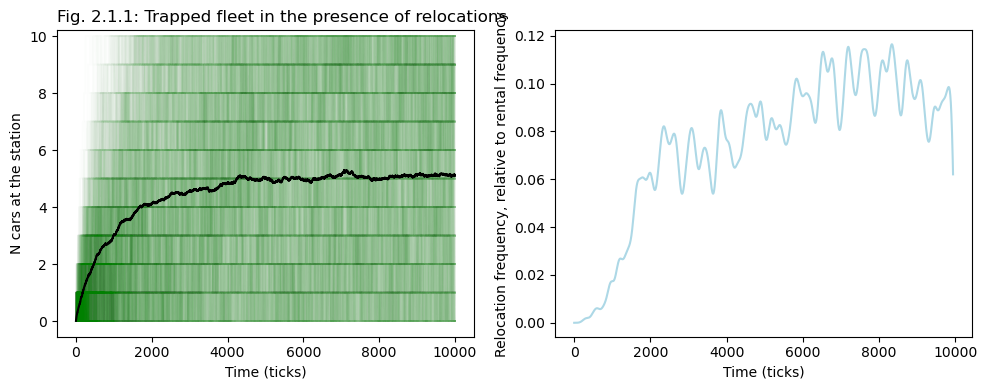

In [43]:
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(out, 'g-', alpha=0.01);
plt.plot(out.mean(axis=1), 'k-');
plt.xlabel('Time (ticks)')
plt.ylabel('N cars at the station')
plt.ylim(None, 10.2)
plt.title("Fig. 2.1.1: Trapped fleet in the presence of relocations", loc='left')

plt.subplot(122)
l = 4000
r = 8000
print("Rate of relos, relative to rentals:", sum(relos[l:r])/(r-l)/n_experiments/p0)
w = 55 # Convolution window width
for i in range(3):
    relos = np.convolve(relos, np.ones(w)/w, mode='same')
plt.plot(relos[:-w] / n_experiments / p0, '-', color='lightblue');
plt.xlabel('Time (ticks)')
plt.ylabel('Relocation frequency, relative to rental frequency');

plt.tight_layout()
plt.savefig("../figures/02relocations_01village_01basic.png", dpi=300) # Png as vector gets too heavy here

1 2 3 4 5 6 7 8 9 

,N_CARS,RELO_RATE
0,1.0,0.518000
1,2.0,0.329600
2,3.0,0.243250
3,4.0,0.198909
4,5.0,0.153000
5,6.0,0.137882
6,7.0,0.128900
7,8.0,0.096174
8,9.0,0.090308


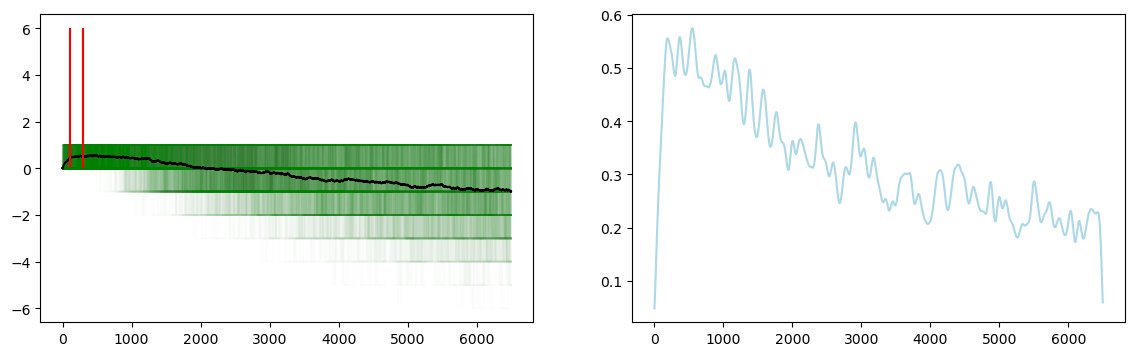

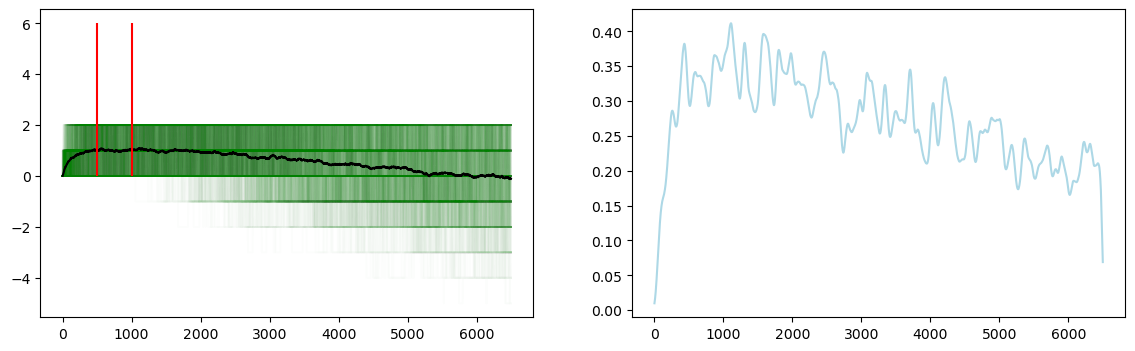

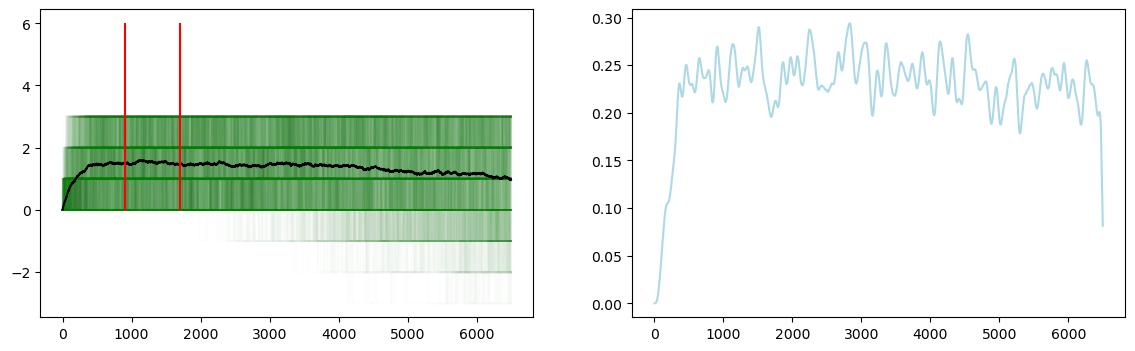

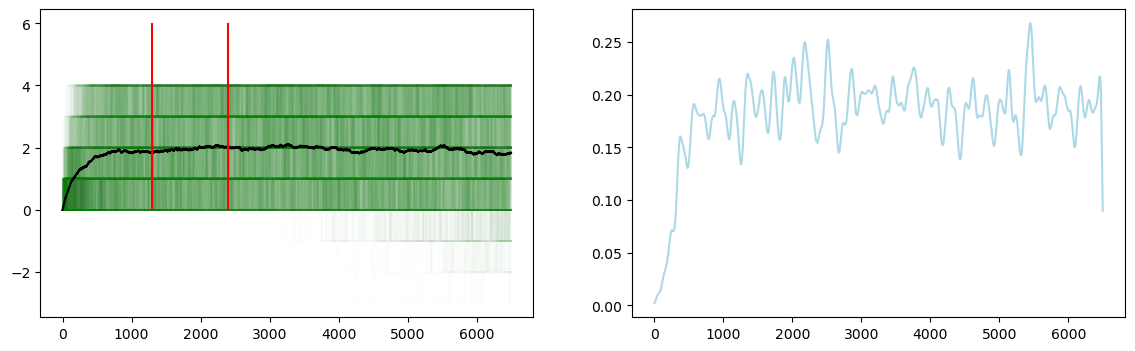

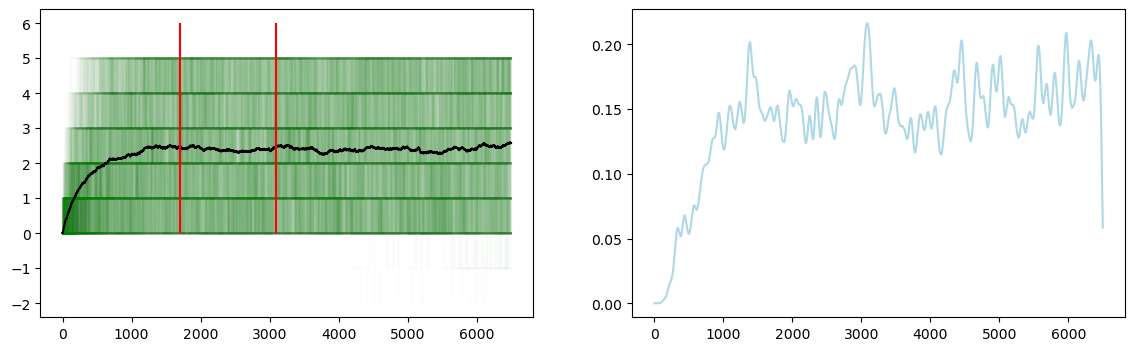

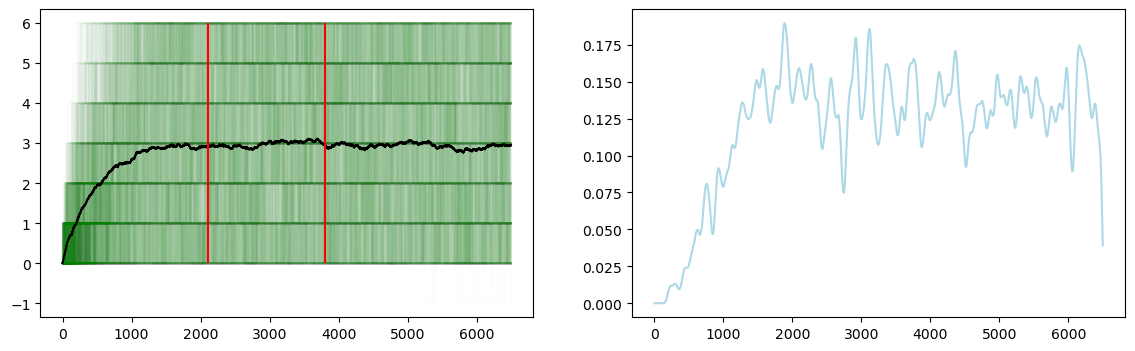

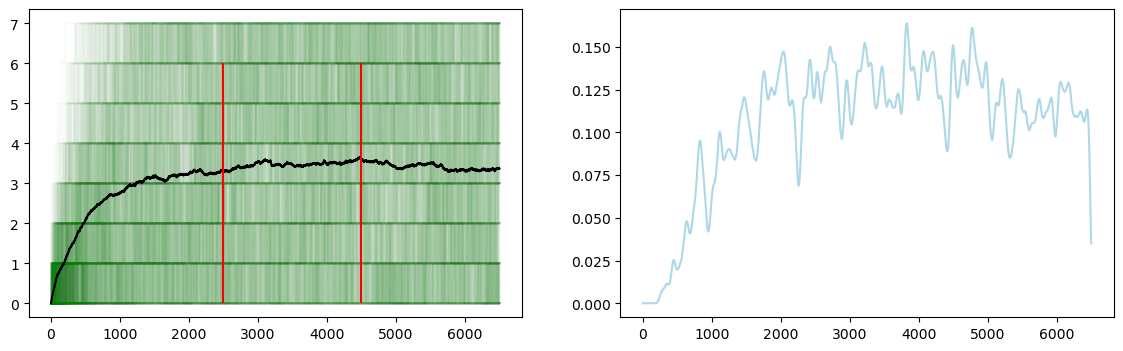

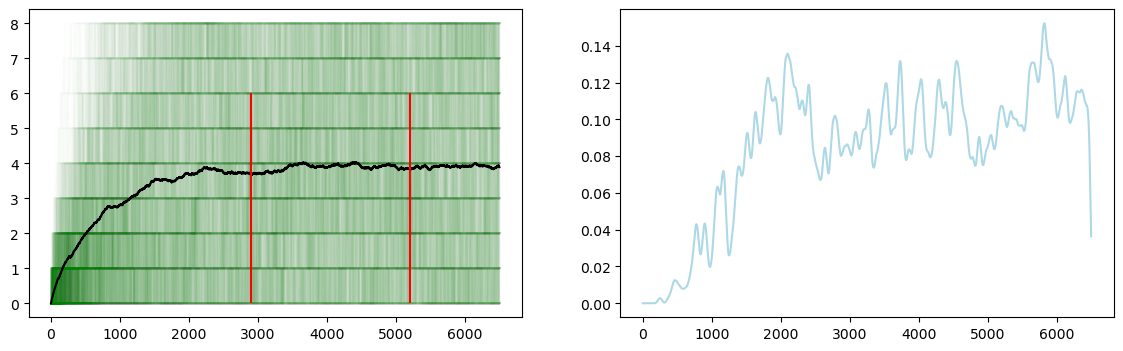

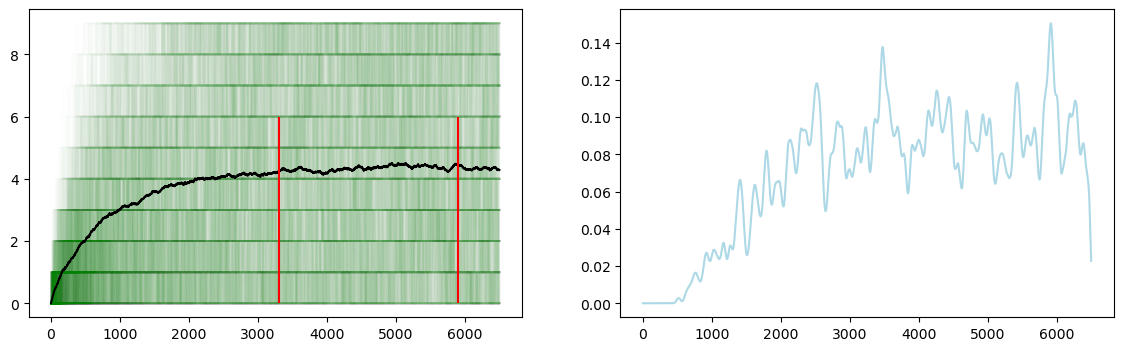

In [44]:
# Relocation counter, automated
# These figures are not saved (they are troubleshooting-purpose only)
t_max = 6500
p0 = 0.01
n_experiments = 500

meta = None
for n_cars in range(1, 10):
    out = None
    relos = np.zeros(shape=(t_max-1))
    for i in range(n_experiments):
        demand_to = (np.random.uniform(size=(t_max)) < p0)*1
        demand_from = (np.random.uniform(size=(t_max)) < p0)*1
        cars = np.cumsum(demand_to - demand_from)
        
        for i_guardian in range(3): # How many time can the process hit the borders
            cars = cars - np.minimum.accumulate(cars.clip(None,0))
            guardian = np.maximum.accumulate(cars.clip(n_cars,None))
            cars = cars - guardian + n_cars
                        
            relos += np.diff(guardian)
        
        if out is None:
            out = cars[:, np.newaxis]
        else:
            out = np.concatenate((out, cars[:, np.newaxis]), axis=1)            

    # Left and right borders for good averaging. Because edge-bouncing here is approximate, 
    # eventually the process escapes from the bounds, but if by that time it became stationary,
    # we will still get a good estimation. Just pick the averaging range carefully :)
    l = 500 + (n_cars-2)*400
    r = 1000 + (n_cars-2)*700
    val = sum(relos[l:r])/(r-l)/n_experiments/p0
    if meta is None:
        meta = pd.DataFrame({'N_CARS':[n_cars], 'RELO_RATE':[val]})
    else:
        meta.loc[len(meta)] = [n_cars, val]    
    print(n_cars, end=' ')
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.plot(out, 'g-', alpha=0.01);
    plt.plot(out.mean(axis=1), 'k-');
    plt.vlines([l, r], 0, 6, 'r')
    
    plt.subplot(122)    
    w = 55 # Convolution window width
    for i in range(3): # How many times co convole to imitate gaussian convolution lol
        relos = np.convolve(relos, np.ones(w)/w, mode='same')
    plt.plot(relos / n_experiments / p0, '-', color='lightblue');

meta

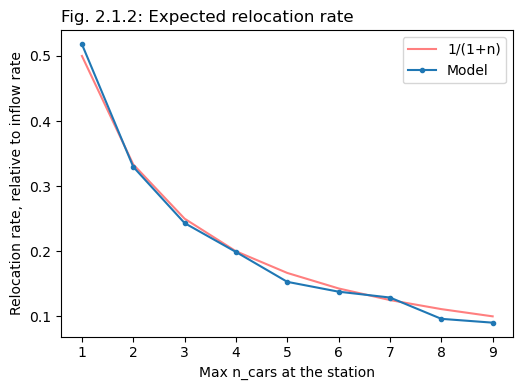

In [45]:
# A summary chart to save
x = meta.N_CARS.values
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(x, 1/(1+x), 'r-', alpha=0.5, label="1/(1+n)")
plt.plot(meta.N_CARS, meta.RELO_RATE, '.-', label='Model');
plt.xlabel('Max n_cars at the station')
plt.ylabel('Relocation rate, relative to inflow rate');
plt.legend();
plt.title("Fig. 2.1.2: Expected relocation rate", loc='left')

plt.tight_layout()
plt.savefig("../figures/02relocations_01village_02relo_freq.svg", dpi=300) 

This means that the total cost of running a hub with relocations is combined of three parts:

1. The average cost of cars trapped in the hub: $N / 2$
2. The expected rate of relocations
3. The expected rate of missed return trips (that happens to be equal to the relocation rate, as both borders of the $[0, N]$ interval are equally distant from the $N/2$ average fleet value.

$$\text{cost} = \frac{N}{2} c_\text{car} + \frac{\lambda}{N+1}(c_\text{relo} + c_\text{trip})$$

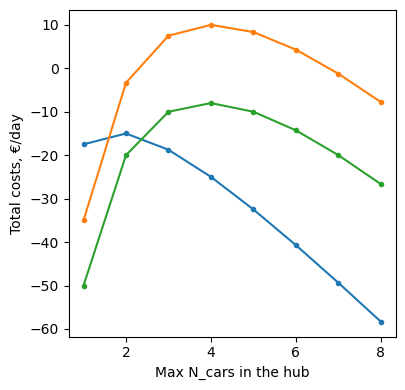

In [46]:
n_cars = np.arange(1, 9)
car_cost = 20
relo_cost = 20
cm1_trip = 5

# Typical small hub that is slightly unprofitable
plt.figure(figsize=(11, 4))
plt.subplot(131)
trip_rate = 3
plt.plot(n_cars, 2*trip_rate*cm1_trip - (n_cars/2*car_cost + 1/(n_cars + 1)*trip_rate*(relo_cost+cm1_trip)), '.-');
plt.xlabel('Max N_cars in the hub')
plt.ylabel('Total costs, €/day');

# Small profitable hub
#plt.subplot(132)
trip_rate = 10
plt.plot(n_cars, 2*trip_rate*cm1_trip - (n_cars/2*car_cost + 1/(n_cars + 1)*trip_rate*(relo_cost+cm1_trip)), '.-');
plt.xlabel('Max N_cars in the hub')
plt.ylabel('Total costs, €/day');

# A satellite in a neirhboring city
car_cost = 20 # A different set of constants
relo_cost = 100
cm1_trip = 20
trip_rate = 2
plt.plot(n_cars, 2*trip_rate*cm1_trip - (n_cars/2*car_cost + 1/(n_cars + 1)*trip_rate*(relo_cost+cm1_trip)), '.-');
plt.xlabel('Max N_cars in the hub')
plt.ylabel('Total costs, €/day');

plt.tight_layout()

In [47]:
def optimal_n(daily_rentals, car_cost=20, relo_cost=20, cm1_trip=5):
    out = np.round(np.sqrt(2*(relo_cost+cm1_trip)*daily_rentals / car_cost) - 1)
    out = np.maximum(out, 1)
    return out.astype(int)

optimal_n(14)

np.int64(5)

$$ \huge N_\text{opt} = \sqrt{\frac{\strut2 (c_\text{relo} + c_\text{trip}) \lambda}{c_\text{car}}} - 1$$

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3052390135.py:13: SyntaxWarning: invalid escape sequence '\l'
  label=f"$\lambda$ = {trip_rate}");
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3052390135.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Fig. 2.1.3: Station profitability for different $N_{\max}$", loc='left')
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3052390135.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Optimal $N_{\max}$');


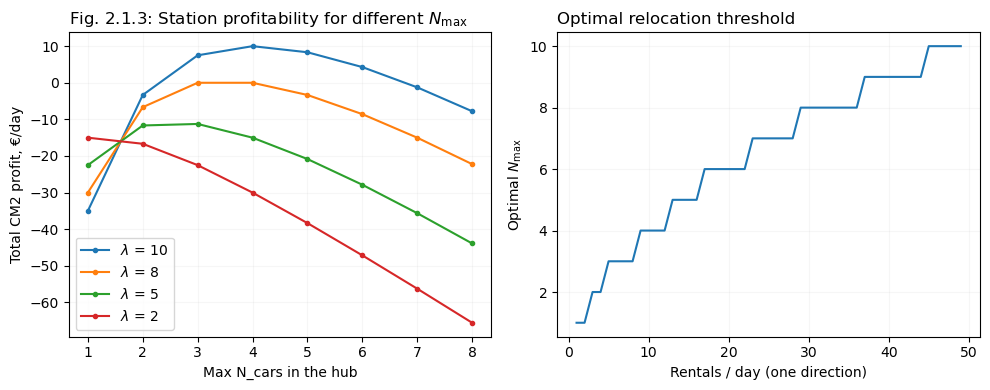

In [48]:
# A better version
n_cars = np.arange(1, 9)
car_cost = 20
relo_cost = 20
cm1_trip = 5

# Typical small hub that is slightly unprofitable
plt.figure(figsize=(10, 4))
plt.subplot(121)

for i, trip_rate in enumerate([10, 8, 5, 2]):
    plt.plot(n_cars, 2*trip_rate*cm1_trip - (n_cars/2*car_cost + 1/(n_cars + 1)*trip_rate*(relo_cost+cm1_trip)), '.-',
            label=f"$\lambda$ = {trip_rate}");
    
plt.xlabel('Max N_cars in the hub')
plt.ylabel('Total CM2 profit, €/day');
plt.legend()
plt.grid(alpha=0.1)
plt.title("Fig. 2.1.3: Station profitability for different $N_{\max}$", loc='left')

plt.subplot(122)
x = range(1, 50)
plt.plot(x, [optimal_n(i) for i in x])
plt.xlabel('Rentals / day (one direction)')
plt.ylabel('Optimal $N_{\max}$');
plt.grid(alpha=0.1)
plt.title("Optimal relocation threshold", loc='left')

plt.tight_layout()
plt.savefig("../figures/02relocations_01village_03cost_curves.svg", dpi=300) 

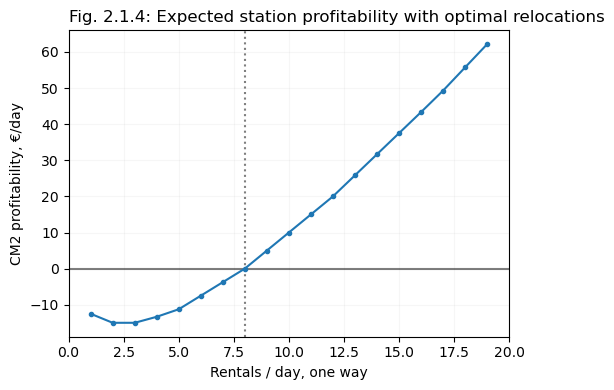

In [49]:
# CM2 as a function of volume
plt.figure(figsize=(10, 4))
plt.subplot(121)

car_cost = 20
relo_cost = 20
cm1_trip = 5
df = (pd.DataFrame({'RENTALS_PER_DAY': range(1,20)})
      .eval("OPTIMAL_CARS = @optimal_n(RENTALS_PER_DAY, @car_cost, @relo_cost, @cm1_trip)")
      .eval("CM2_PER_DAY = RENTALS_PER_DAY*(@cm1_trip*2 - (@relo_cost+@cm1_trip)/(1+OPTIMAL_CARS)) " +
            "- OPTIMAL_CARS/2*@car_cost")
     )

plt.axhline(0, color='k', alpha=0.5)
plt.axvline(8, color='k', alpha=0.5, linestyle=":")
plt.plot(df.RENTALS_PER_DAY, df.CM2_PER_DAY, '.-')
plt.xlim(0, 20)
plt.grid(alpha=0.1)
plt.xlabel('Rentals / day, one way')
plt.ylabel('CM2 profitability, €/day');
plt.title("Fig. 2.1.4: Expected station profitability with optimal relocations", loc='left')

plt.tight_layout()
plt.savefig("../figures/02relocations_01village_04ideal_profitability.svg", dpi=300)

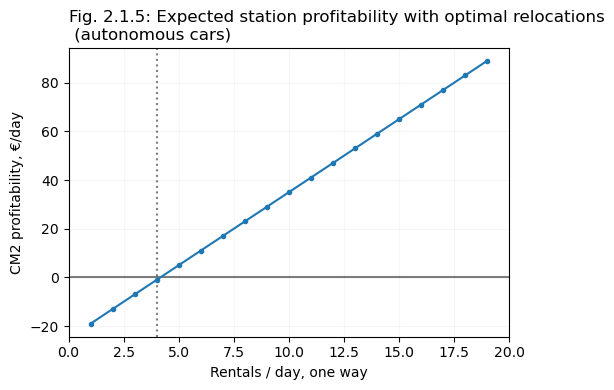

In [50]:
# CM2 as a function of volume - for autonomous relocations!
plt.figure(figsize=(10, 4))
plt.subplot(121)

car_cost = 50  # Assume that autonoous cars are way more expensive
relo_cost = 3  # But relocation cost now is electricity + amorization
cm1_trip = 5
df = (pd.DataFrame({'RENTALS_PER_DAY': range(1,20)})
      .eval("OPTIMAL_CARS = @optimal_n(RENTALS_PER_DAY, @car_cost, @relo_cost, @cm1_trip)")
      .eval("CM2_PER_DAY = RENTALS_PER_DAY*(@cm1_trip*2 - (@relo_cost+@cm1_trip)/(1+OPTIMAL_CARS)) " +
            "- OPTIMAL_CARS/2*@car_cost")
     )

plt.axhline(0, color='k', alpha=0.5)
plt.axvline(4, color='k', alpha=0.5, linestyle=":")
plt.plot(df.RENTALS_PER_DAY, df.CM2_PER_DAY, '.-')
plt.xlim(0, 20)
plt.grid(alpha=0.1)
plt.xlabel('Rentals / day, one way')
plt.ylabel('CM2 profitability, €/day');
plt.title("Fig. 2.1.5: Expected station profitability with optimal relocations\n (autonomous cars)", loc='left')

plt.tight_layout()
plt.savefig("../figures/02relocations_01village_05autonomous.svg", dpi=300)

# ==== Pricing ====

Elasticity $L$ for a price of $R$:

$\huge L(R) = L_0 + b(R-0.30)$

Demand $D$:

$\huge D(R) = D_0 \cdot (R/R_0)^{L(R)}$

b = -0.06 (Berlin)

$L_0 = -0.8$ for the price insensitive area, $-2.0$ for the sensitive area

$D_0$ is the initial demand level at price $R_0$

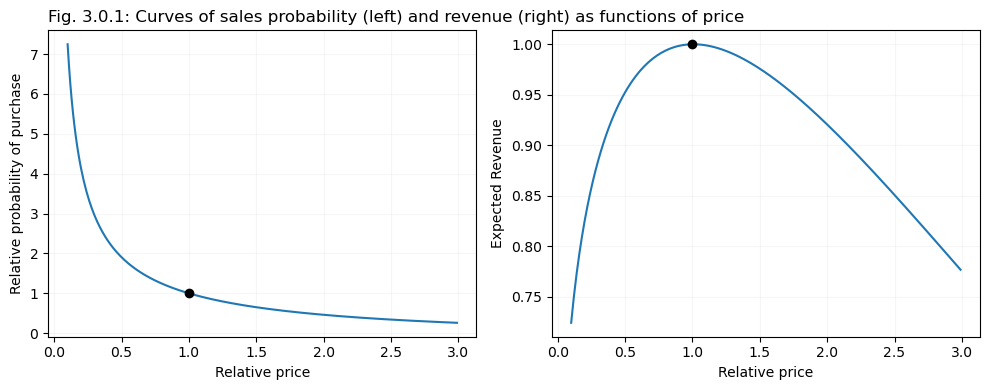

In [52]:
def p_trip(r, p0=None, r0=0.1):
    if p0 is None:
        p0 = 1/p_trip(1, 1) # Auto-normalization
    b = -0.06
    e = -0.8
    return p0 * (r / r0)**(e + b*r)

x = np.arange(0.1, 3, 0.01)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(x, list(map(p_trip, x)));
plt.plot(1,1,'ko')
plt.grid(alpha=0.1)
plt.xlabel('Relative price')
plt.ylabel('Relative probability of purchase');
plt.title("Fig. 3.0.1: Curves of sales probability (left) and revenue (right) as functions of price", loc='left')

plt.subplot(122)
plt.plot(x, x*np.array(list(map(p_trip, x, [None]*len(x))))); # also to test normalization
plt.plot(1,1,'ko')
plt.grid(alpha=0.1)
plt.xlabel('Relative price')
plt.ylabel('Expected Revenue');

plt.tight_layout()
plt.savefig("../figures/03pricing_00basic_01curves.svg", dpi=300)

In [16]:
# Normalizing coefficient:
1/p_trip(1, 1)

7.244359600749902

........Done


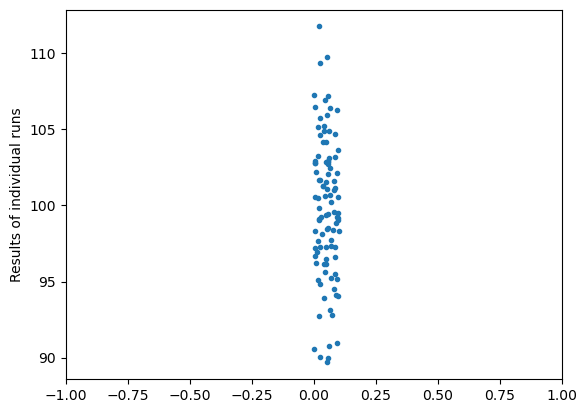

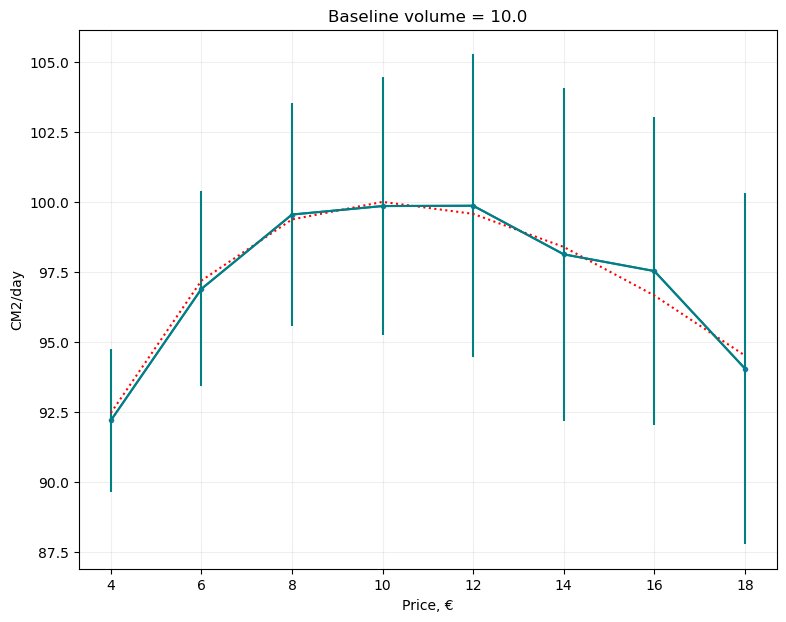

In [17]:
# No fleet and relo costs (should replicate the curve above)
N_EXP = 100
DEMAND = 100 # Demand, one direction (100 for default volume of 10 in base conditions)
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

prices = np.arange(0.4, 2, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
for i_price, price in enumerate(prices):
    final_cm2 = np.empty(shape=N_EXP)    
    max_cars = 5    
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)

        t = 0        
        money = 0    
        for i in range(N_STEPS):
            t += steps[i]
            if direction[i]: # True = traveling right
                if dice[i] < BASE_P * p_trip(price):                                    
                    money += price*BASE_CM1                    
            else:
                if dice[i] < BASE_P * p_trip(price):                                        
                    money += price*BASE_CM1                    

        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    print('.', end='')
    if np.isclose(price, 1, 0.01): # Troubleshooting plot, to happen once
        plt.plot(np.random.uniform(size=N_EXP)/10, final_cm2, '.');
        plt.xlim(-1, 1)
        plt.ylabel('Results of individual runs')


print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.plot(x, BASE_CM1*2*results.PRICE.values*DEMAND*BASE_P * 
         np.array(list(map(p_trip, results.PRICE.values))), 'r:');

## Optimizing for hub CM2, symmetric prices

Max cars: 7
.Max cars: 5
.Max cars: 5
.Max cars: 4
.Max cars: 4
.Max cars: 3
.Max cars: 3
.Max cars: 3
.Done


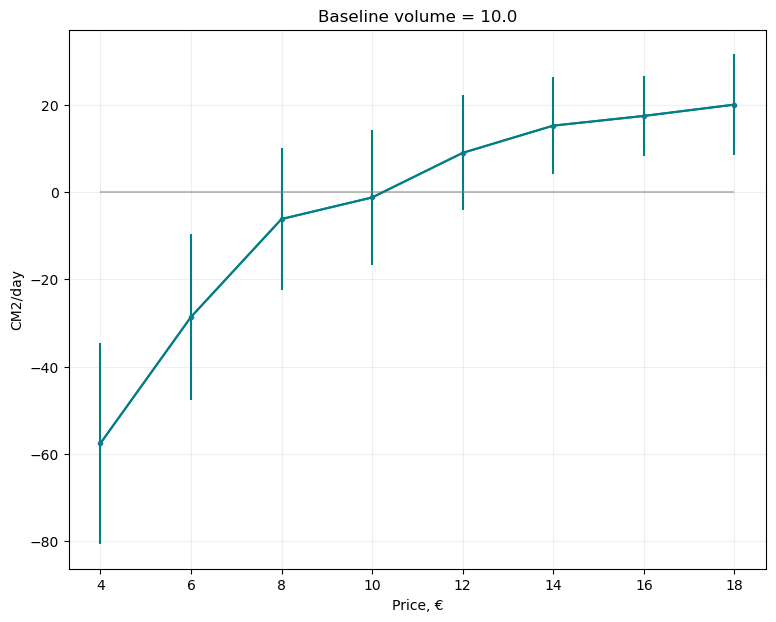

In [18]:
# Break-even hub, optimize price symmetrically
N_EXP = 100
DEMAND = 100 # Demand, one direction (100 for default volume of 10 in base conditions)
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

prices = np.arange(0.4, 2, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
for i_price, price in enumerate(prices):
    final_cm2 = np.empty(shape=N_EXP)
    
    max_cars = optimal_n(DEMAND * BASE_P * p_trip(price))
    print('Max cars:', max_cars)
    
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)

        t = 0
        cars = 0    
        money = 0    
        for i in range(N_STEPS):
            t += steps[i]
            money -= steps[i]*COST_CAR*cars

            if direction[i]: # True = traveling right
                if dice[i] < BASE_P * p_trip(price):
                    if cars < max_cars:
                        cars += 1
                        money += price*BASE_CM1
                    else:
                        money += price*BASE_CM1 - COST_RELO
            else:
                if dice[i] < BASE_P * p_trip(price):
                    if cars > 0:
                        cars -= 1
                        money += price*BASE_CM1        
            #plt.plot(t, money, 'k.')

        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    
    print('.', end='')    
print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

Max cars: 4
.Max cars: 2
.Max cars: 2
.Max cars: 1
.Max cars: 1
.Max cars: 1
.Max cars: 1
.Max cars: 1
.Max cars: 1
.Done


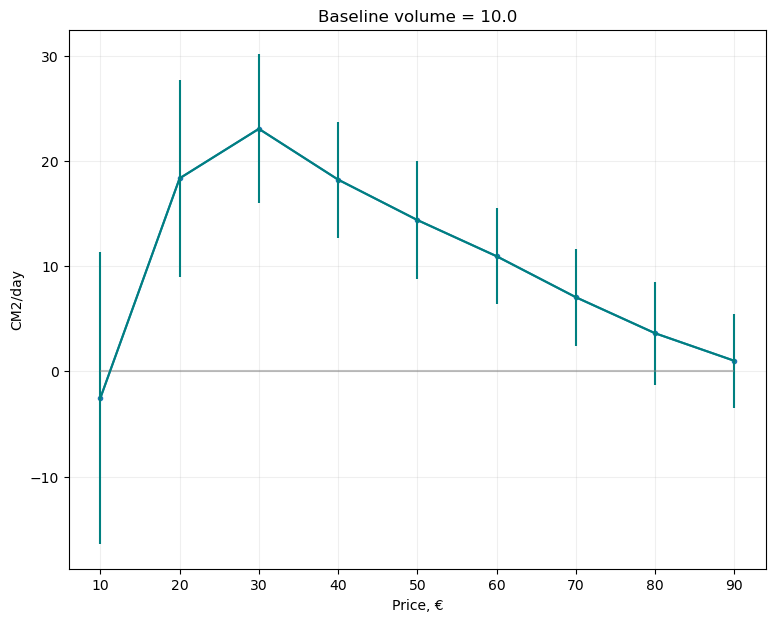

In [19]:
# Same experiment, different scale
N_EXP = 100
DEMAND = 100 # Demand, one direction (100 for default volume of 10 in base conditions)
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

prices = np.arange(1, 10, 1)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
for i_price, price in enumerate(prices):
    final_cm2 = np.empty(shape=N_EXP)
    
    max_cars = optimal_n(DEMAND * BASE_P * p_trip(price))
    print('Max cars:', max_cars)
    
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)

        t = 0
        cars = 0    
        money = 0    
        for i in range(N_STEPS):
            t += steps[i]
            money -= steps[i]*COST_CAR*cars

            if direction[i]: # True = traveling right
                if dice[i] < BASE_P * p_trip(price):
                    if cars < max_cars:
                        cars += 1
                        money += price*BASE_CM1
                    else:
                        money += price*BASE_CM1 - COST_RELO
            else:
                if dice[i] < BASE_P * p_trip(price):
                    if cars > 0:
                        cars -= 1
                        money += price*BASE_CM1        
            #plt.plot(t, money, 'k.')

        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    
    print('.', end='')    
print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

So, basically, a low-fleet luxury operator model.

## Drop-fee

Max cars: 4
...........Done


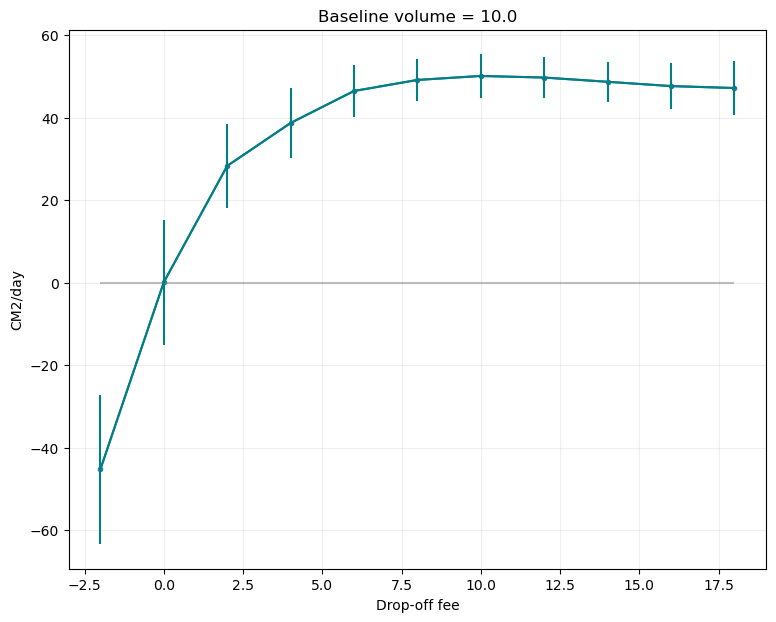

In [20]:
# Drop-fee only (return price remains constant)
N_EXP = 100
DEMAND = 100 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

max_cars = optimal_n(DEMAND * BASE_P)
print('Max cars:', max_cars)

price_right = 1 # Normalized prices
price_left = 1

prices = np.arange(0.8, 3, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
for i_price, price_right in enumerate(prices):
    final_cm2 = np.empty(shape=N_EXP)
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)

        t = 0
        cars = 0    
        money = 0    
        for i in range(N_STEPS):
            t += steps[i]
            money -= steps[i]*COST_CAR*cars

            if direction[i]: # True = traveling right
                if dice[i] < BASE_P * p_trip(price_right):
                    if cars < max_cars:
                        cars += 1
                        money += price_right*BASE_CM1
                    else:
                        money += price_right*BASE_CM1 - COST_RELO
            else:
                if dice[i] < BASE_P:
                    if cars > 0:
                        cars -= 1
                        money += price_left*BASE_CM1        
            #plt.plot(t, money, 'k.')

        final_cm2[i_exp] = money/t # Average revenue a day    

    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)
    
    print('.', end='')      

print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = (results.PRICE.values - 1)*BASE_CM1*2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Drop-off fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

Max cars: 6
...........Done


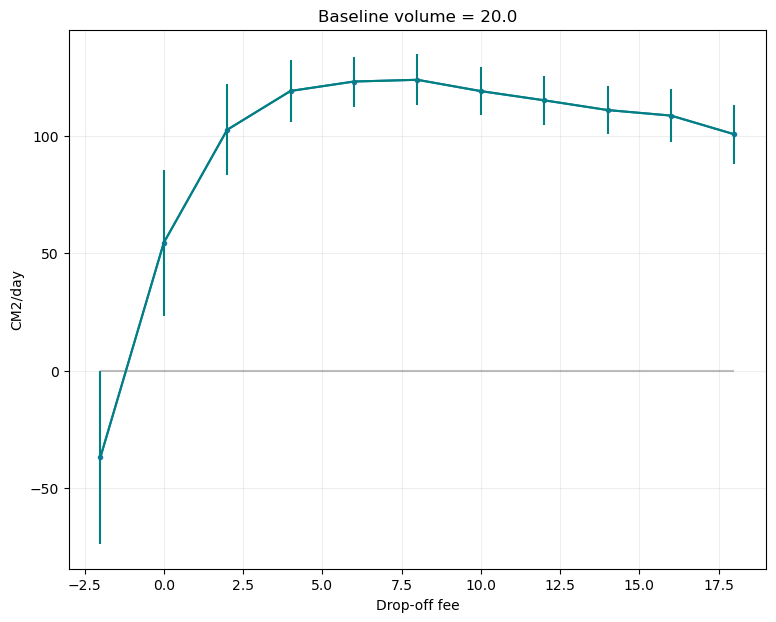

In [21]:
# Same thing, but in a high-volume ~50 trips/day hub
N_EXP = 100
DEMAND = 200 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

max_cars = optimal_n(DEMAND * BASE_P)
print('Max cars:', max_cars)

price_right = 1 # Normalized prices
price_left = 1

prices = np.arange(0.8, 3, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
for i_price, price_right in enumerate(prices):
    final_cm2 = np.empty(shape=N_EXP)
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)

        t = 0
        cars = 0    
        money = 0    
        for i in range(N_STEPS):
            t += steps[i]
            money -= steps[i]*COST_CAR*cars

            if direction[i]: # True = traveling right
                if dice[i] < BASE_P * p_trip(price_right):
                    if cars < max_cars:
                        cars += 1
                        money += price_right*BASE_CM1
                    else:
                        money += price_right*BASE_CM1 - COST_RELO
            else:
                if dice[i] < BASE_P:
                    if cars > 0:
                        cars -= 1
                        money += price_left*BASE_CM1        
            #plt.plot(t, money, 'k.')

        final_cm2[i_exp] = money/t # Average revenue a day    

    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)
    
    print('.', end='')      

print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = (results.PRICE.values - 1)*BASE_CM1*2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Drop-off fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

# Full asymmetrical price optimization

## Normal-volume hub

Max cars: 4
.....|.....|.....|.....|.....|.....|.....|.....|Done


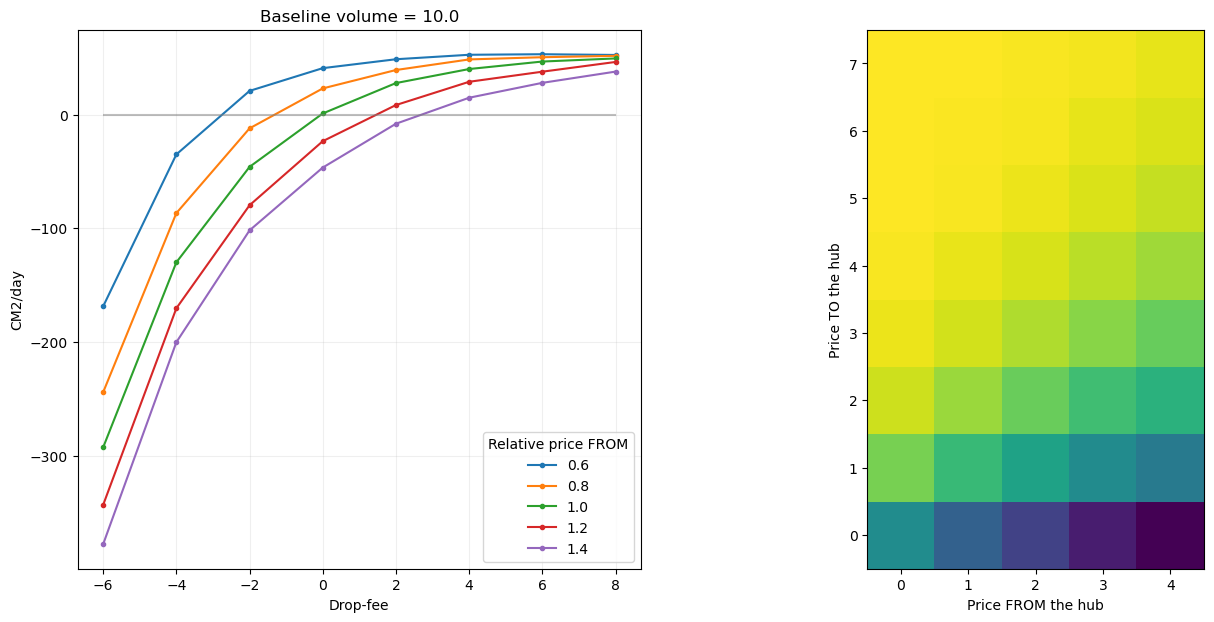

In [22]:
# Optimize both prices
N_EXP = 100
DEMAND = 100 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

max_cars = optimal_n(DEMAND * BASE_P)
print('Max cars:', max_cars)

price_right = 1 # Normalized prices
price_left = 1

prices = np.round(np.arange(0.4, 2, 0.2), 1)
out = []
for i_price, price_right in enumerate(prices):
    for j_price, price_left in enumerate(np.round(np.arange(0.6, 1.6, 0.2), 1)):
        final_cm2 = np.empty(shape=N_EXP)
        for i_exp in range(N_EXP):
            steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
            direction = (np.random.uniform(size=N_STEPS) < 0.5)
            dice = np.random.uniform(size=N_STEPS)

            t = 0
            cars = 0    
            money = 0    
            for i in range(N_STEPS):
                t += steps[i]
                money -= steps[i]*COST_CAR*cars

                if direction[i]: # True = traveling right
                    if dice[i] < BASE_P * p_trip(price_right):
                        if cars < max_cars:
                            cars += 1
                            money += price_right*BASE_CM1
                        else:
                            money += price_right*BASE_CM1 - COST_RELO
                else:
                    if dice[i] < BASE_P * p_trip(price_left):
                        if cars > 0:
                            cars -= 1
                            money += price_left*BASE_CM1        
                #plt.plot(t, money, 'k.')

            final_cm2[i_exp] = money/t # Average revenue a day    

        out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])

        print('.', end='')
    print('|', end='')

results = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
print('Done')

# Overall results
plt.figure(figsize=(16,7))
plt.subplot(121)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

plt.subplot(122)
plt.imshow(view.iloc[:,1:].values, origin='lower');
plt.ylabel('Price TO the hub')
plt.xlabel('Price FROM the hub');

## Same, but high-volume hub

Max cars: 7
.....|.....|.....|.....|.....|.....|.....|.....|Done


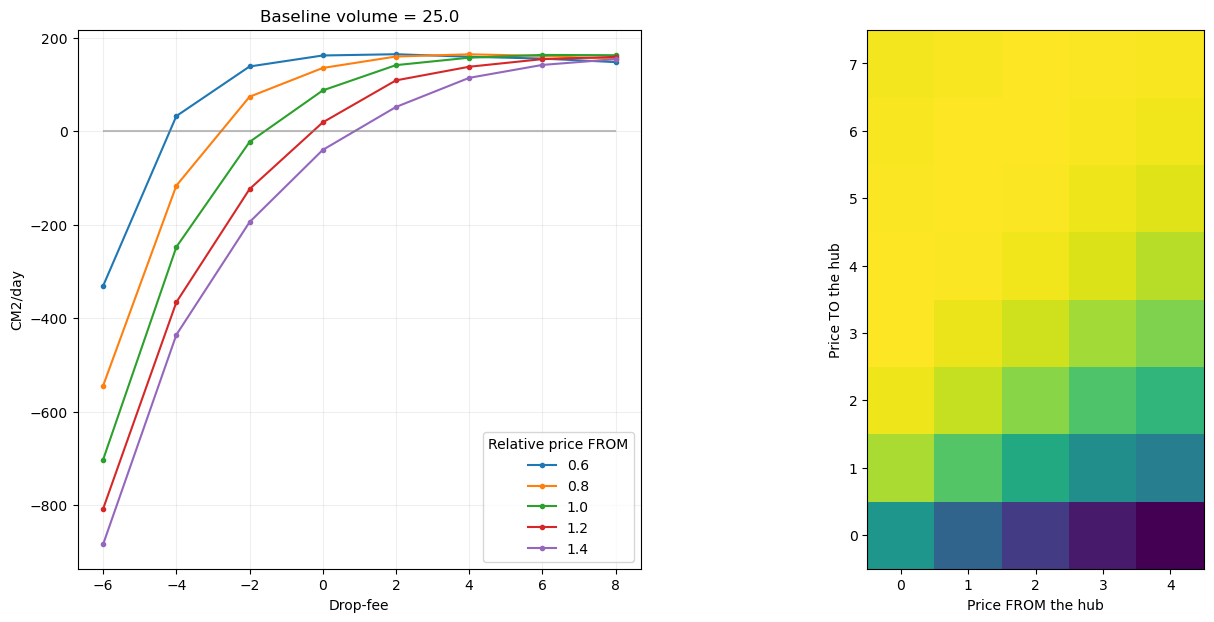

In [23]:
# Optimize both prices
N_EXP = 100
DEMAND = 250 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

max_cars = optimal_n(DEMAND * BASE_P)
print('Max cars:', max_cars)

price_right = 1 # Normalized prices
price_left = 1

prices = np.round(np.arange(0.4, 2, 0.2), 1)
out = []
for i_price, price_right in enumerate(prices):
    for j_price, price_left in enumerate(np.round(np.arange(0.6, 1.6, 0.2), 1)):
        final_cm2 = np.empty(shape=N_EXP)
        for i_exp in range(N_EXP):
            steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
            direction = (np.random.uniform(size=N_STEPS) < 0.5)
            dice = np.random.uniform(size=N_STEPS)

            t = 0
            cars = 0    
            money = 0    
            for i in range(N_STEPS):
                t += steps[i]
                money -= steps[i]*COST_CAR*cars

                if direction[i]: # True = traveling right
                    if dice[i] < BASE_P * p_trip(price_right):
                        if cars < max_cars:
                            cars += 1
                            money += price_right*BASE_CM1
                        else:
                            money += price_right*BASE_CM1 - COST_RELO
                else:
                    if dice[i] < BASE_P * p_trip(price_left):
                        if cars > 0:
                            cars -= 1
                            money += price_left*BASE_CM1        
                #plt.plot(t, money, 'k.')

            final_cm2[i_exp] = money/t # Average revenue a day    

        out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])

        print('.', end='')
    print('|', end='')

results = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
print('Done')

# Overall results
plt.figure(figsize=(16,7))
plt.subplot(121)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

plt.subplot(122)
plt.imshow(view.iloc[:,1:].values, origin='lower');
plt.ylabel('Price TO the hub')
plt.xlabel('Price FROM the hub');

In a high-volume hub a drop-fee and a return discount have the same effect, and do not stack. One is enough (and return discount is probably easier to impelement)

### Same, but in a low-volume hub

Max cars: 3
.....|.....|.....|.....|.....|.....|.....|.....|.....|Done


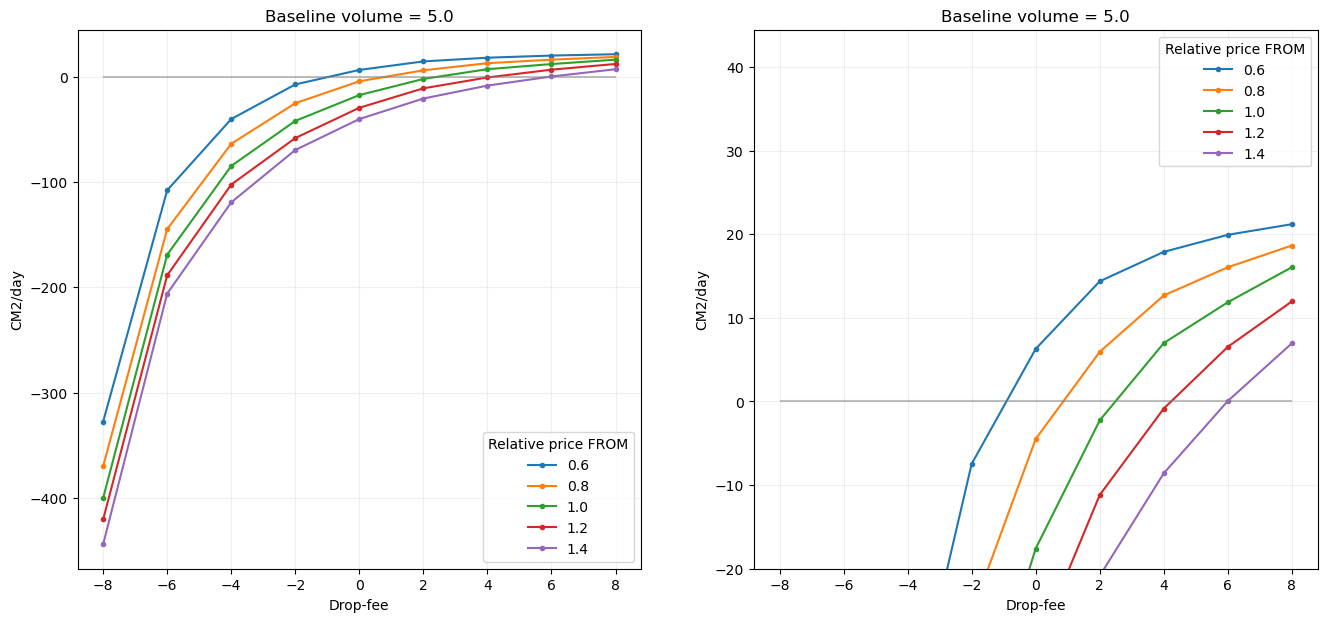

In [24]:
# Again Optimize both prices
N_EXP = 100
DEMAND = 50 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

max_cars = optimal_n(DEMAND * BASE_P)
print('Max cars:', max_cars)

price_right = 1 # Normalized prices
price_left = 1

prices = np.round(np.arange(0.2, 2, 0.2), 1)
out = []
for i_price, price_right in enumerate(prices):
    for j_price, price_left in enumerate(np.round(np.arange(0.6, 1.6, 0.2), 1)):
        final_cm2 = np.empty(shape=N_EXP)
        for i_exp in range(N_EXP):
            steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
            direction = (np.random.uniform(size=N_STEPS) < 0.5)
            dice = np.random.uniform(size=N_STEPS)

            t = 0
            cars = 0    
            money = 0    
            for i in range(N_STEPS):
                t += steps[i]
                money -= steps[i]*COST_CAR*cars

                if direction[i]: # True = traveling right
                    if dice[i] < BASE_P * p_trip(price_right):
                        if cars < max_cars:
                            cars += 1
                            money += price_right*BASE_CM1
                        else:
                            money += price_right*BASE_CM1 - COST_RELO
                else:
                    if dice[i] < BASE_P * p_trip(price_left):
                        if cars > 0:
                            cars -= 1
                            money += price_left*BASE_CM1        
                #plt.plot(t, money, 'k.')

            final_cm2[i_exp] = money/t # Average revenue a day    

        out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])

        print('.', end='')
    print('|', end='')

results = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
print('Done')


# Overall results
plt.figure(figsize=(16,7))
plt.subplot(121)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

plt.subplot(122)
plt.plot(x, view.iloc[:, 1:], '.-');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);
plt.ylim(-20, None);

In a low-volume hub, effects of drop-fee and discount do stack, so both need to be implemented.

# Competition, no fleet costs, no car availability

No fleet and relo coss. The 2nd operator always keeps the prices at the one-perator optimum.

How to model elasticity with competition? One option is to use a softmax function for operator choice. That way, when having two operators with probabilities of use $p$ and $p_0$, we first pick if it is us, or our competitor who will be even considered:

$$\huge \frac{b^p}{b^p + b^{p_0}}$$

Then, if it's us, we check if the user will use us:

$$\huge p\frac{b^p}{b^p + b^{p_0}}$$

The function gives $p/2$ when prices are identical (chance), is similar to "our" curve when we are cheaper, and approaches 0 when we are more expensive.

Let's pick base $b$ so that we could steal back half of the customers by lowering the price 2 times.

Competitor's customers stolen at half-price: [0.50030087]


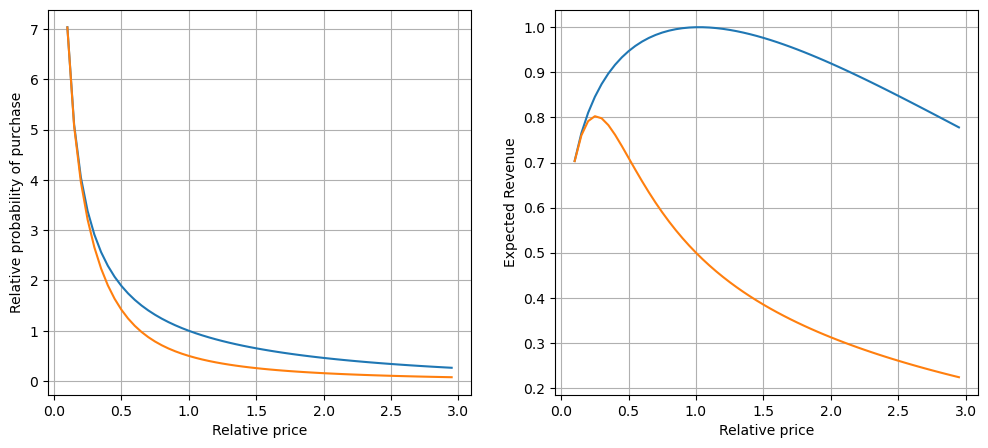

In [25]:
# How could cross-elasticity look like?
def p_trip(r, p0=8.3868, r0=0.08):
    # r is the relative price, with 1 corresponding to the default (optimal) price
    if p0 is None:
        p0 = 1/p_trip(1, 1) # Auto-normalization
    b = -0.06
    e = -0.8
    return p0 * (r / r0)**(e + b*(r - 0.3))

x = np.arange(0.1, 3, 0.05)
plt.figure(figsize=(12,5))
plt.subplot(121)
y = np.array(list(map(p_trip, x)))
COMPETE = 1.23
# Aggressiveness coefficient
y_prime = y * np.exp(y*COMPETE)/(np.exp(1*COMPETE) + np.exp(y*COMPETE))
plt.plot(x, y);
plt.plot(x, y_prime);
plt.grid()
plt.xlabel('Relative price')
plt.ylabel('Relative probability of purchase');
print("Competitor's customers stolen at half-price:",
      (y_prime[np.isclose(x, 0.5)] / y[np.isclose(x, 0.5)]-0.5)*2)

plt.subplot(122)
plt.plot(x, x*y);
plt.plot(x, x*y_prime)
plt.grid()
plt.xlabel('Relative price')
plt.ylabel('Expected Revenue');

Lowering of the price is now most profitable. Let's model this.

..................Done


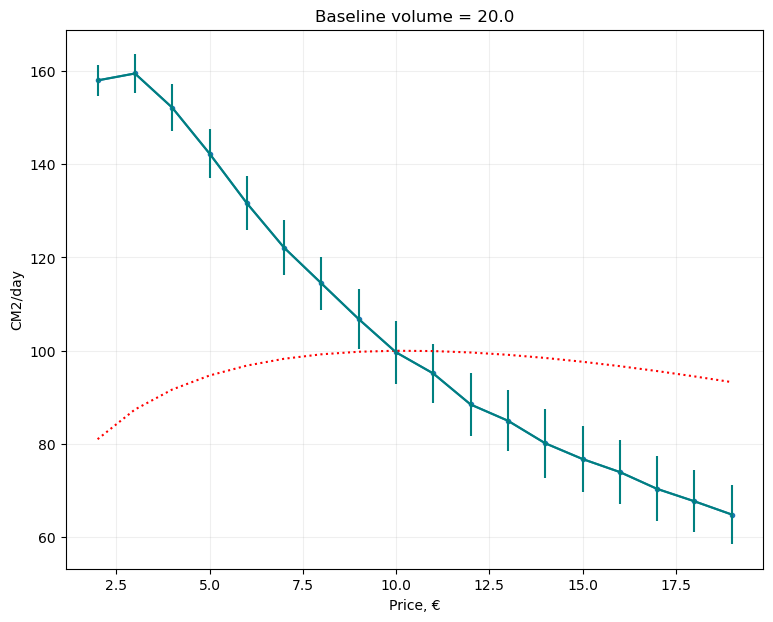

In [26]:
# No fleet and relo costs, no car availability, only naive competition
N_EXP = 200
DEMAND = 200 # Double the underlying demand, to arrive to the same total volume "at rest"
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

prices = np.arange(0.2, 2, 0.1)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
for i_price, price in enumerate(prices):
    p  = p_trip(price)
    p0 = 1            
    p_prime = p * np.exp(p*COMPETE)/(np.exp(p0*COMPETE) + np.exp(p*COMPETE))    
    final_cm2 = np.empty(shape=N_EXP)    
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)        

        t = 0        
        money = 0
        for i in range(N_STEPS):
            t += steps[i]            
            if direction[i]: # True = wants to travel right
                if dice[i] < p_prime*BASE_P:
                    money += price*BASE_CM1                    
            else:
                if dice[i] < p_prime*BASE_P:
                    money += price*BASE_CM1                    

        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    print('.', end='')

print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.plot(x, BASE_CM1*2*results.PRICE.values*DEMAND/2*BASE_P * 
         np.array(list(map(p_trip, results.PRICE.values))), 'r:');

So as expected (kinda by design), from the revenue maximization point of view it's better to go super-cheap.

## Now with car costs and relo costs, symmetric prices, smallish hub

At this point we stop optimizing target n_cars for evey price, as we don't know probabilities of customer behavior upfront, so it is fair to assume that we'll estimate target n_cars roughly , assuming whatever would be the current split with the competitor, and then we'll start fighting.

Max cars: 4
.........Done


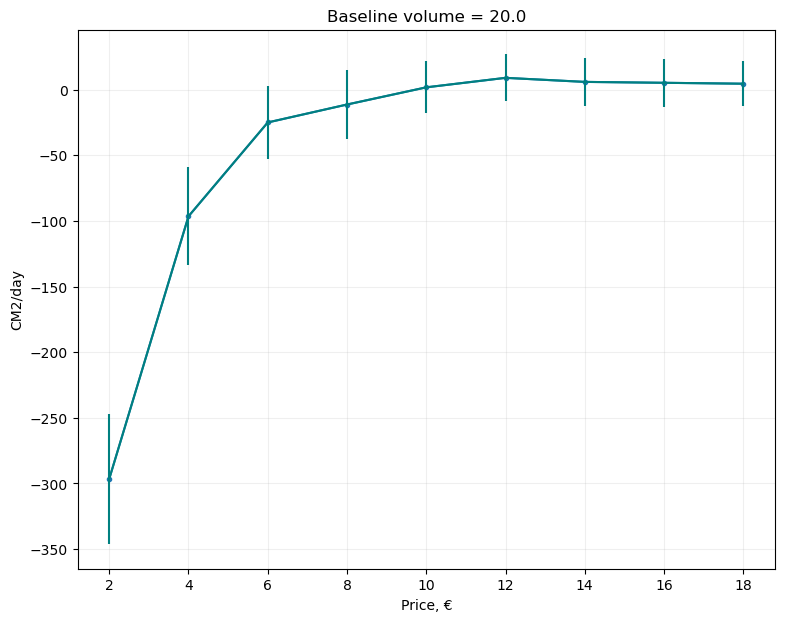

In [27]:
# With full costs, but symmetric prices
N_EXP = 100
DEMAND = 200 # Double the underlying demand, to arrive to the same total volume "at rest"
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

prices = np.arange(0.2, 2, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
max_cars = optimal_n(DEMAND/2 * BASE_P) # Approximate
print('Max cars:', max_cars)
cars0 = optimal_n(DEMAND/2 * BASE_P)/2 # That's how many cars our competitor will have, on average
for i_price, price in enumerate(prices):    
    p =  p_trip(price)
    p0 = 1
    ep =  np.exp(p) # To avoid calculating exp in a loop
    ep0 = np.exp(p0)
    p_prime = p * np.exp(p*COMPETE)/(np.exp(p0*COMPETE) + np.exp(p*COMPETE))        
    
    final_cm2 = np.empty(shape=N_EXP)
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)        

        t = 0        
        money = 0
        cars = 0        
        for i in range(N_STEPS):
            t += steps[i]
            money -= cars*COST_CAR*steps[i]
            if direction[i]: # True = wants to travel to the hub
                if dice[i] < p_prime*BASE_P:
                    money += price*BASE_CM1  
                    if cars < max_cars:
                        cars += 1
                    else:
                        money -= COST_RELO
            else:
                if dice[i] < p_prime*BASE_P:
                    if cars > 0:
                        money += price*BASE_CM1                    
                        cars -= 1
                        
        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    print('.', end='')

print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)

In a smallish hub one can just suffer. You cannot lower the price to get volumes as it means spending more, and you cannot increase the price, as it means losing customers. The best strategy is just to suffer it through.

What about a big hub though? Is there any difference?

Max cars: 7
.........Done


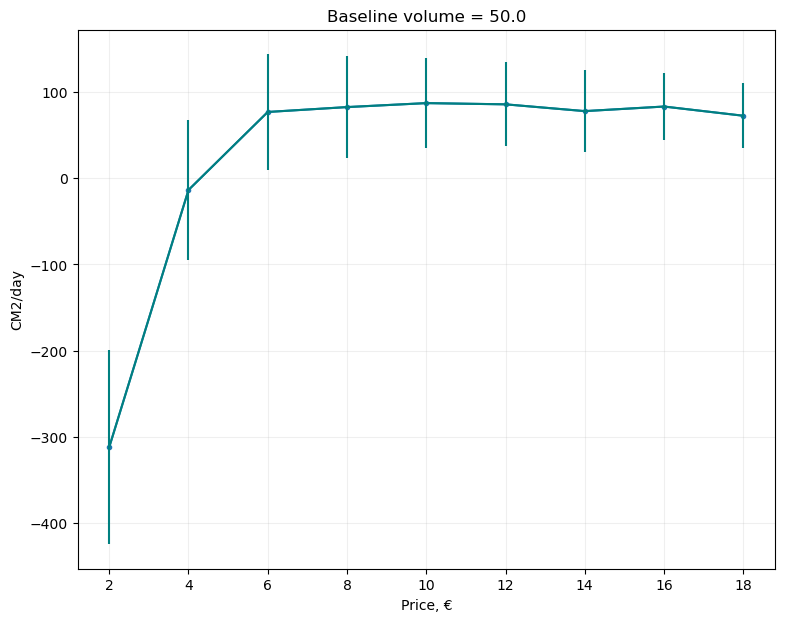

In [28]:
# With full costs, but symmetric prices
N_EXP = 100
DEMAND = 500 # Double the underlying demand, to arrive to the same total volume "at rest"
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

prices = np.arange(0.2, 2, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
max_cars = optimal_n(DEMAND/2 * BASE_P) # Approximate
print('Max cars:', max_cars)
cars0 = optimal_n(DEMAND/2 * BASE_P)/2 # That's how many cars our competitor will have, on average
for i_price, price in enumerate(prices):    
    p =  p_trip(price)
    p0 = 1    
    p_prime = p * np.exp(p*COMPETE)/(np.exp(p0*COMPETE) + np.exp(p*COMPETE))        
    
    final_cm2 = np.empty(shape=N_EXP)
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)        

        t = 0        
        money = 0
        cars = 0        
        for i in range(N_STEPS):
            t += steps[i]
            money -= cars*COST_CAR*steps[i]
            if direction[i]: # True = wants to travel to the hub
                if dice[i] < p_prime*BASE_P:
                    money += price*BASE_CM1  
                    if cars < max_cars:
                        cars += 1
                    else:
                        money -= COST_RELO
            else:
                if dice[i] < p_prime*BASE_P:
                    if cars > 0:
                        money += price*BASE_CM1                    
                        cars -= 1
                        
        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    print('.', end='')

print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)

For a big hub, we can try to undercut prices a bit, but with realistic financial numbers, there's much space for maneuver.

## Drop-fee (our competitor doesn't have a drop-fee!)

........Done


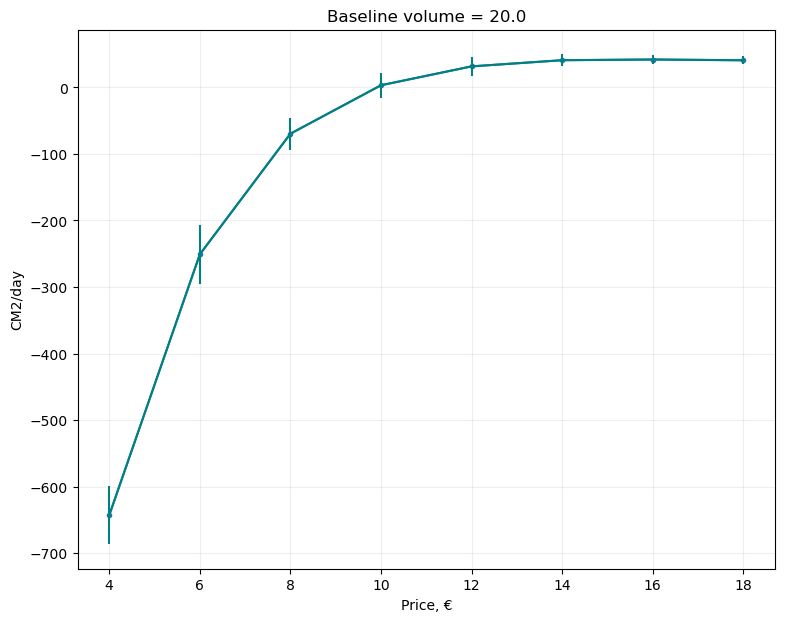

In [29]:
# Drop-fee
N_EXP = 100
DEMAND = 200 # Double the underlying demand, to arrive to the same total volume "at rest"
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

prices = np.arange(0.4, 2, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
price_left = 1 # Constant for now
max_cars = optimal_n(DEMAND/2 * BASE_P)
cars0 = max_cars/2 # That's how many cars our competitor will have, on average
for i_price, price_right in enumerate(prices):    
    pR = p_trip(price_right)
    pL = p_trip(price_left)
    p0 = p_trip(1)    
    pR_prime = pR * np.exp(pR*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pR*COMPETE))
    pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pL*COMPETE))
    

    final_cm2 = np.empty(shape=N_EXP)
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)        

        t = 0        
        money = 0
        cars = 0        
        for i in range(N_STEPS):
            t += steps[i]
            money -= cars*COST_CAR*steps[i]
            if direction[i]: # True = wants to travel to the hub
                if dice[i] < pR_prime * BASE_P:
                    money += price_right*BASE_CM1  
                    if cars < max_cars:
                        cars += 1
                    else:
                        money -= COST_RELO
            else:
                if dice[i] < pL_prime * BASE_P:
                    if cars > 0:
                        money += price_left*BASE_CM1                    
                        cars -= 1
                        
        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    print('.', end='')

print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)

........Done


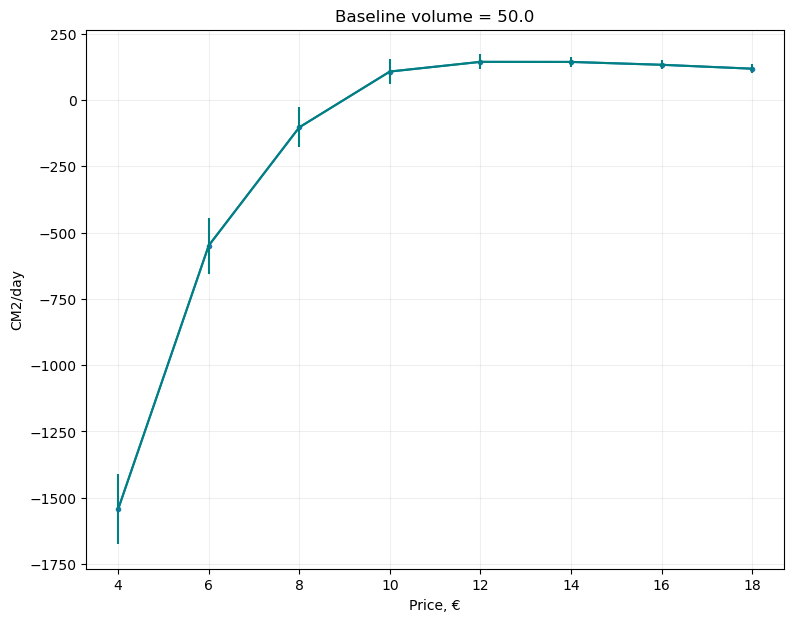

In [30]:
# Same, but a large hub
N_EXP = 100
DEMAND = 500 # Double the underlying demand, to arrive to the same total volume "at rest"
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

prices = np.arange(0.4, 2, 0.2)
results = pd.DataFrame({'PRICE':prices, 'CM2': None, 'STD': None})
price_left = 1 # Constant for now
max_cars = optimal_n(DEMAND/2 * BASE_P)
cars0 = max_cars/2 # That's how many cars our competitor will have, on average
for i_price, price_right in enumerate(prices):    
    pR = p_trip(price_right)
    pL = p_trip(price_left)
    p0 = p_trip(1)    
    pR_prime = pR * np.exp(pR*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pR*COMPETE))
    pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pL*COMPETE))
    

    final_cm2 = np.empty(shape=N_EXP)
    for i_exp in range(N_EXP):
        steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
        direction = (np.random.uniform(size=N_STEPS) < 0.5)
        dice = np.random.uniform(size=N_STEPS)        

        t = 0        
        money = 0
        cars = 0        
        for i in range(N_STEPS):
            t += steps[i]
            money -= cars*COST_CAR*steps[i]
            if direction[i]: # True = wants to travel to the hub
                if dice[i] < pR_prime * BASE_P:
                    money += price_right*BASE_CM1  
                    if cars < max_cars:
                        cars += 1
                    else:
                        money -= COST_RELO
            else:
                if dice[i] < pL_prime * BASE_P:
                    if cars > 0:
                        money += price_left*BASE_CM1                    
                        cars -= 1
                        
        final_cm2[i_exp] = money/t # Average revenue a day
        
    results.loc[i_price, 'CM2'] = np.mean(final_cm2)
    results.loc[i_price, 'STD'] = np.std(final_cm2)    
    print('.', end='')

print('Done')

# Overall results
plt.figure(figsize=(9,7))
x = results.PRICE.values * BASE_CM1 * 2
plt.plot(x, results.CM2, '.-');
plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.xlabel('Price, €')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)

It's actually useful to put a drop fee. The size of the drop-fee doesn't matter that much, as costs and benefits roughly counteract each other...

## Optimizing both prices when our competitor does NOT have a drop fee

### For a "normal-sized" hub

Max cars: 4
......|......|......|......|......|......|......|......|......|......|......|......|......|......|Done


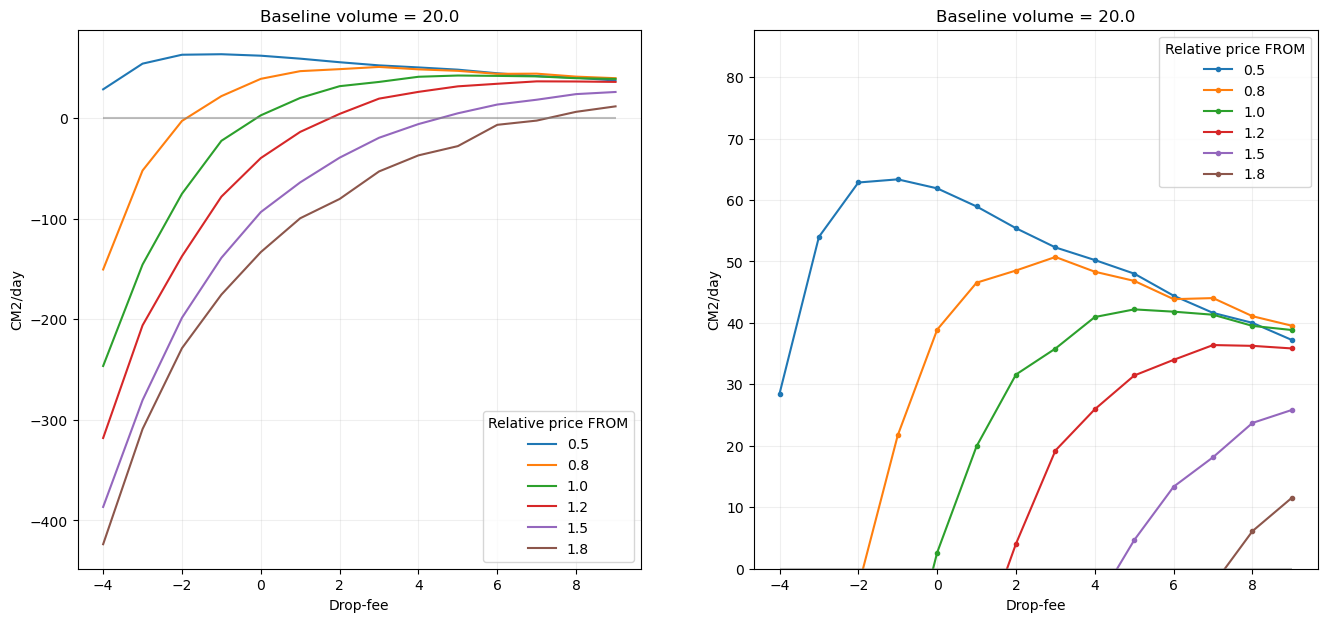

In [31]:
# Optimize both prices
N_EXP = 100
DEMAND = 200 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

price_right = 1 # Normalized prices
price_left = 1

prices = np.round(np.arange(0.6, 2, 0.1), 1)
out = []
max_cars = optimal_n(DEMAND/2 * BASE_P)
print('Max cars:', max_cars)
cars0 = max_cars/2 # That's how many cars our competitor will have, on average
for i_price, price_right in enumerate(prices):
    for j_price, price_left in enumerate(np.round(np.arange(0.5, 2, 0.25), 1)):        
        pR = p_trip(price_right)
        pL = p_trip(price_left)
        p0 = 1
        pR_prime = pR * np.exp(pR*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pR*COMPETE))
        pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pL*COMPETE))

        final_cm2 = np.empty(shape=N_EXP)
        for i_exp in range(N_EXP):
            steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
            direction = (np.random.uniform(size=N_STEPS) < 0.5)
            dice = np.random.uniform(size=N_STEPS)

            t = 0
            cars = 0    
            money = 0    
            for i in range(N_STEPS):
                t += steps[i]
                money -= steps[i]*COST_CAR*cars
                if direction[i]: # True = traveling right
                    if dice[i] < pR_prime*BASE_P:
                        money += price_right*BASE_CM1
                        if cars < max_cars:
                            cars += 1                            
                        else:
                            money -= COST_RELO
                else:
                    if dice[i] < pL_prime*BASE_P:
                        if cars > 0:
                            cars -= 1
                            money += price_left*BASE_CM1        
            final_cm2[i_exp] = money/t # Average revenue a day   

        out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])
        print('.', end='')
    print('|', end='')

results = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
print('Done')


# Overall results
plt.figure(figsize=(16,7))
plt.subplot(121)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

plt.subplot(122)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5)
plt.ylim(0, None);

#plt.imshow(view.iloc[:,1:].values, origin='lower');
#plt.ylabel('Price TO the hub')
#plt.xlabel('Price FROM the hub');

Putting a drop-fee (4€ in this case) helps, but discounting return trips helps even more. And then there's some stacking of effects involved. 

So in this particular case a 4€ drop-fee was good, but a 2€ drop-fee combined with a 2€ return discount was even better, and discounting everything worked the best!!

Interestingly, this effect was impossible to notice when we changed prices symmetrically, as (-2, -2) is worse than (0, 0), but (-2, -4) is way better!

The good news for us, practically, is that CM2 seems to be more sensitive to return prices, and these are more visible, easier to change, and they can be automated. Which means that once return prices are optimized, most of the effect will be captured!

Another important practical note: having a drop-fee is NOT always better. It is a "safe" and "dumb" solution, but it may prevent a better strategy of asymmetric price-dumping.

## Same, but for a small hub

I have to pick a really tiny hub here, so that even stealing all customers from the 2nd operator wouldn't make it profitable, otherwise we just get a discount strategy, very similar to a "medum hub" situation.

Max cars: 2
......|......|......|......|......|......|......|......|......|......|......|......|......|......|Done


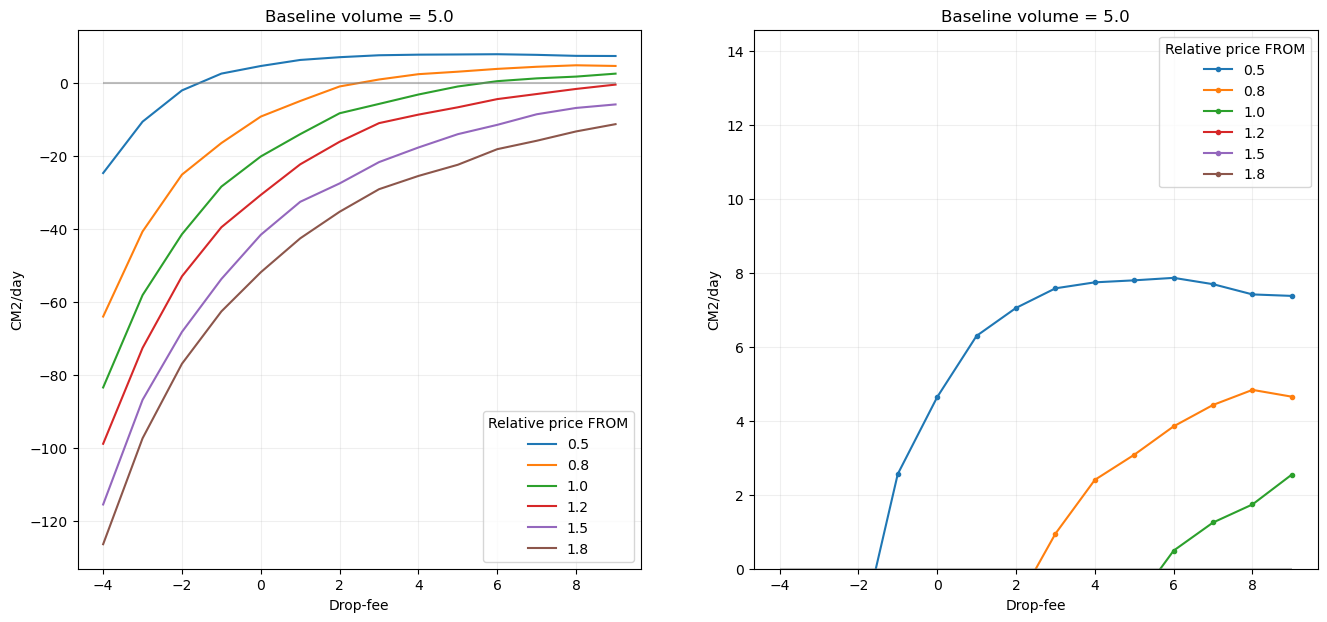

In [32]:
# Optimize both prices
N_EXP = 100
DEMAND = 50 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

price_right = 1 # Normalized prices
price_left = 1

prices = np.round(np.arange(0.6, 2, 0.1), 1)
out = []
max_cars = optimal_n(DEMAND/2 * BASE_P)
print('Max cars:', max_cars)
cars0 = max_cars/2 # That's how many cars our competitor will have, on average
for i_price, price_right in enumerate(prices):
    for j_price, price_left in enumerate(np.round(np.arange(0.5, 2, 0.25), 1)):        
        pR = p_trip(price_right)
        pL = p_trip(price_left)
        p0 = 1
        pR_prime = pR * np.exp(pR*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pR*COMPETE))
        pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0*COMPETE) + np.exp(pL*COMPETE))

        final_cm2 = np.empty(shape=N_EXP)
        for i_exp in range(N_EXP):
            steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
            direction = (np.random.uniform(size=N_STEPS) < 0.5)
            dice = np.random.uniform(size=N_STEPS)

            t = 0
            cars = 0    
            money = 0    
            for i in range(N_STEPS):
                t += steps[i]
                money -= steps[i]*COST_CAR*cars
                if direction[i]: # True = traveling right
                    if dice[i] < pR_prime*BASE_P:
                        money += price_right*BASE_CM1
                        if cars < max_cars:
                            cars += 1                            
                        else:
                            money -= COST_RELO
                else:
                    if dice[i] < pL_prime*BASE_P:
                        if cars > 0:
                            cars -= 1
                            money += price_left*BASE_CM1        
            final_cm2[i_exp] = money/t # Average revenue a day   

        out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])
        print('.', end='')
    print('|', end='')

results = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
print('Done')


# Overall results
plt.figure(figsize=(16,7))
plt.subplot(121)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

plt.subplot(122)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5)
plt.ylim(0, None);

#plt.imshow(view.iloc[:,1:].values, origin='lower');
#plt.ylabel('Price TO the hub')
#plt.xlabel('Price FROM the hub');

A combined strategy of a small fee (2€) and return discount works best. A difference here is that discounting TO-HUB trips doesn't work. Note that disconting return truips still has a way stronger effect than a drop-fee.

## Optimizing both prices when our competitor has a 5€ drop-fee; small hub

For medium-sized and large hubs, there's really no visible difference between curves with and without competitor's drop-fee.

For a small hub (below), a presence of a drop-fee just makes discounting strategy more viable, as it helps to get under competitor prices on both legs, and steal their customers. Interestingly, in this probabilistic model not reciprocating a drop-fee is really not that much of a risk, as long as return trips are cheap enough.

Max cars: 2
......|......|......|......|......|......|......|......|......|......|......|......|......|......|Done


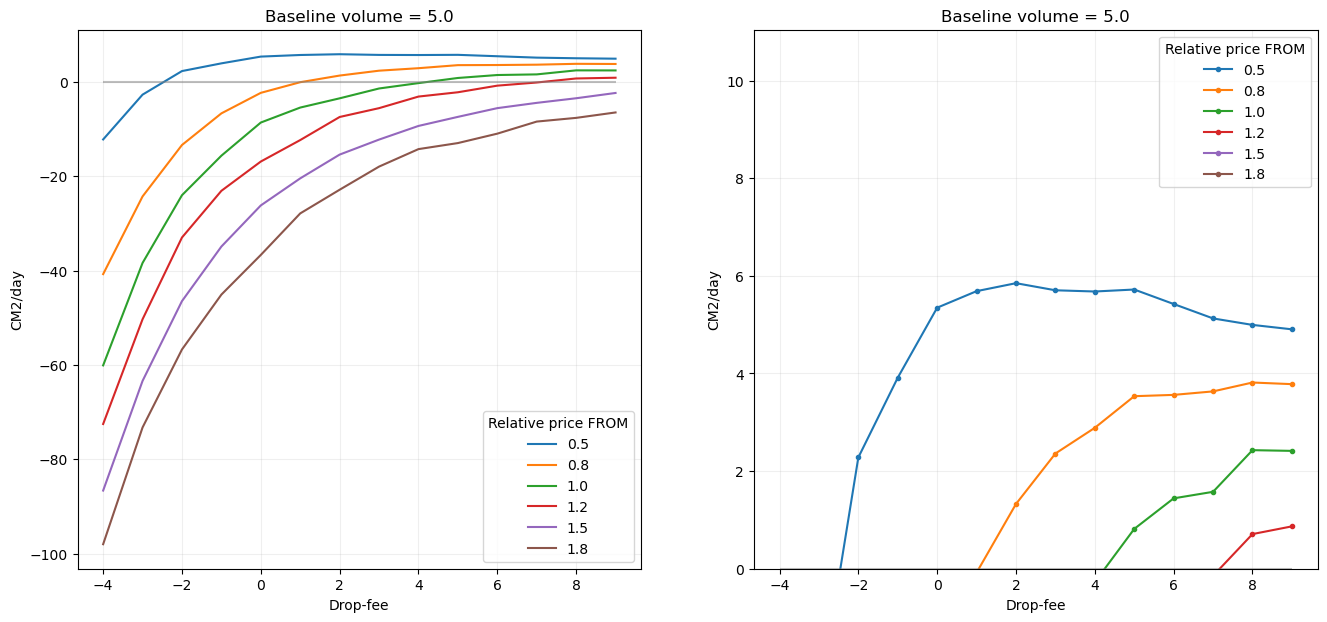

In [33]:
# Optimize both prices
N_EXP = 100
DEMAND = 50 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 1.23

prices = np.round(np.arange(0.6, 2, 0.1), 1)
out = []
max_cars = optimal_n(DEMAND/2 * BASE_P)
print('Max cars:', max_cars)
cars0 = max_cars/2 # That's how many cars our competitor will have, on average
for i_price, price_right in enumerate(prices):
    for j_price, price_left in enumerate(np.round(np.arange(0.5, 2, 0.25), 1)):        
        pR = p_trip(price_right)
        pL = p_trip(price_left)
        p0R = 1.5 # < ------ Drop Fee of our competitor!
        p0L = 1
        pR_prime = pR * np.exp(pR*COMPETE)/(np.exp(p0R*COMPETE) + np.exp(pR*COMPETE))
        pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))

        final_cm2 = np.empty(shape=N_EXP)
        for i_exp in range(N_EXP):
            steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
            direction = (np.random.uniform(size=N_STEPS) < 0.5)
            dice = np.random.uniform(size=N_STEPS)

            t = 0
            cars = 0    
            money = 0    
            for i in range(N_STEPS):
                t += steps[i]
                money -= steps[i]*COST_CAR*cars
                if direction[i]: # True = traveling right
                    if dice[i] < pR_prime*BASE_P:
                        money += price_right*BASE_CM1
                        if cars < max_cars:
                            cars += 1                            
                        else:
                            money -= COST_RELO
                else:
                    if dice[i] < pL_prime*BASE_P:
                        if cars > 0:
                            cars -= 1
                            money += price_left*BASE_CM1        
            final_cm2[i_exp] = money/t # Average revenue a day   

        out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])
        print('.', end='')
    print('|', end='')

results = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
print('Done')


# Overall results
plt.figure(figsize=(16,7))
plt.subplot(121)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

plt.subplot(122)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5)
plt.ylim(0, None);

#plt.imshow(view.iloc[:,1:].values, origin='lower');
#plt.ylabel('Price TO the hub')
#plt.xlabel('Price FROM the hub');

# Optimizing prices for different volumes

## With competition (but much weaker than in examples above, as with aggressive competition discounting is essentially the only strategy)

In [34]:
# Optimize both prices, with competition
N_EXP = 100
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 3000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)
COMPETE = 0.5 # Modest competition

prices_right = np.round(np.arange(0.6, 2, 0.1), 1)
prices_left  = np.round(np.arange(0, 1.1, 0.2), 1) # Only smaller than default

results = [] # In this version, it will be used for meta-results
for demand in np.arange(20, 420, 20):
    max_cars = optimal_n(demand/2 * BASE_P)
    cars0 = max_cars/2 # That's how many cars our competitor will have, on average
    out = []
    for i_price, price_right in enumerate(prices_right):
        for j_price, price_left in enumerate(prices_left):        
            pR = p_trip(price_right)
            pL = p_trip(price_left)
            p0R = 1 # < ------ Drop Fee of our competitor!
            p0L = 1
            pR_prime = pR * np.exp(pR*COMPETE)/(np.exp(p0R*COMPETE) + np.exp(pR*COMPETE))
            pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))

            final_cm2 = np.empty(shape=N_EXP)
            for i_exp in range(N_EXP):
                steps = np.random.exponential(1/(demand*2), N_STEPS) # The param it takes is 1/lambda
                direction = (np.random.uniform(size=N_STEPS) < 0.5)
                dice = np.random.uniform(size=N_STEPS)

                t = 0
                cars = 0    
                money = 0    
                for i in range(N_STEPS):
                    t += steps[i]
                    money -= steps[i]*COST_CAR*cars
                    if direction[i]: # True = traveling right
                        if dice[i] < pR_prime*BASE_P:
                            money += price_right*BASE_CM1
                            if cars < max_cars:
                                cars += 1                            
                            else:
                                money -= COST_RELO
                    else:
                        if dice[i] < pL_prime*BASE_P:
                            if cars > 0:
                                cars -= 1
                                money += price_left*BASE_CM1        
                final_cm2[i_exp] = money/t # Average revenue a day   

            out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])
            #print('.', end='')
        print('|', end='')
    out = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
    i = np.argmax(out['CM2'].values)
    print(i)    
    results.append([demand*BASE_P] + list(out.loc[i, ['PRICE_R', 'PRICE_L']].values))

results = pd.DataFrame(results, columns=['VOLUME', 'PRICE_R', 'PRICE_L'])
print('Done')

results

C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\2003823381.py:8: RuntimeWarning: divide by zero encountered in scalar power
  return p0 * (r / r0)**(e + b*(r - 0.3))
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3584008711.py:26: RuntimeWarning: invalid value encountered in scalar divide
  pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))


||||||||||||||79


C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\2003823381.py:8: RuntimeWarning: divide by zero encountered in scalar power
  return p0 * (r / r0)**(e + b*(r - 0.3))
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3584008711.py:26: RuntimeWarning: invalid value encountered in scalar divide
  pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))


||||||||||||||79


C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\2003823381.py:8: RuntimeWarning: divide by zero encountered in scalar power
  return p0 * (r / r0)**(e + b*(r - 0.3))
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3584008711.py:26: RuntimeWarning: invalid value encountered in scalar divide
  pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))


...

C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\2003823381.py:8: RuntimeWarning: divide by zero encountered in scalar power
  return p0 * (r / r0)**(e + b*(r - 0.3))
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3584008711.py:26: RuntimeWarning: invalid value encountered in scalar divide
  pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))


||||||||||||||1


C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\2003823381.py:8: RuntimeWarning: divide by zero encountered in scalar power
  return p0 * (r / r0)**(e + b*(r - 0.3))
C:\Users\ArsenyKhakhalin\AppData\Local\Temp\ipykernel_6372\3584008711.py:26: RuntimeWarning: invalid value encountered in scalar divide
  pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))


|||||||

KeyboardInterrupt: 

In [ ]:
# Visualize results

plt.figure(figsize=(8,7))
x = results.VOLUME
plt.plot(x, results.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=results.columns[1:], title='Relative price FROM')
plt.xlabel('Flow, one way, cars/day')
plt.ylabel('Ideal prices, relative to default value of ~10€');
plt.grid(alpha=0.2)

### Without explicit competition

In [ ]:
# Optimize both prices, with competition
N_EXP = 20
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 3000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

prices_right = np.round(np.arange(0.5, 2, 0.05), 2)
prices_left  = np.round(np.arange(0, 1.2, 0.05), 2) # Only smaller than default

results = [] # In this version, it will be used for meta-results
for demand in np.arange(20, 420, 20):
    max_cars = optimal_n(demand * BASE_P)
    # max_cars = optimal_n(np.round(demand+np.random.normal(1)*2) * BASE_P) # plot smoother
    out = []
    for i_price, price_right in enumerate(prices_right):
        for j_price, price_left in enumerate(prices_left):        
            pR = p_trip(price_right)
            pL = p_trip(price_left)
            
            final_cm2 = np.empty(shape=N_EXP)
            for i_exp in range(N_EXP):
                steps = np.random.exponential(1/demand, N_STEPS) # The param it takes is 1/lambda
                direction = (np.random.uniform(size=N_STEPS) < 0.5)
                dice = np.random.uniform(size=N_STEPS)

                t = 0
                cars = 0    
                money = 0    
                for i in range(N_STEPS):
                    t += steps[i]
                    money -= steps[i]*COST_CAR*cars
                    if direction[i]: # True = traveling right
                        if dice[i] < pR * BASE_P:
                            money += price_right*BASE_CM1
                            if cars < max_cars:
                                cars += 1                            
                            else:
                                money -= COST_RELO
                    else:
                        if dice[i] < pL * BASE_P:
                            if cars > 0:
                                cars -= 1
                                money += price_left*BASE_CM1        
                final_cm2[i_exp] = money/t # Average revenue a day   

            out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])
            #print('.', end='')
        print('|', end='')
    out = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
    i = np.argmax(out['CM2'].values)
    print(i)    
    results.append([demand*BASE_P] + list(out.loc[i, ['PRICE_R', 'PRICE_L']].values))

results = pd.DataFrame(results, columns=['VOLUME', 'PRICE_R', 'PRICE_L'])
print('Done')

# Visualize results
plt.figure(figsize=(8,7))
x = results.VOLUME
plt.plot(x, results.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=results.columns[1:], title='Relative price FROM')
plt.xlabel('Flow, one way, cars/day')
plt.ylabel('Ideal prices, relative to default value of ~10€');
plt.grid(alpha=0.2)

results

# Conclusions:

1. Fleet cost encourages prices TO the hub to always be higher than prices FROM the hub, and this is one thing that always remains true, for all scenarious tested (but it doesn't mean a drop-fee necessarily; it may as well be achieved through discounting of return trips)
2. Competition and fleet cost have different effects on optimal prices:
    3. Competition encourages discounting in both directions
    4. Fleet costs encourage higher prices in TO the hub direction

Depending on hub volume and competition intensity (and so also demand cross-elasticity) we observe optimal prices switch between "discount-or-die" strategy and "hike the prices and enjoy high revenues at low effort" strategy.

* For small hubs, drop-fees are good
* For medium and large hubs drop-fees are detrimental, as they prevent price-undercuttong
* For very high-volume hubs, we can try to increase drop-fees again (??)

### Other notes:

1. Discounting of return trips usually has a much higher effect on revenue than drop-fees than drop-fees
1. Typically there's no use in increasing a drop-fee beyond a rather small amount (~2€ ?). Profits remain flat as CM1/trip growth and trips/day decline just compensate for each other.
1. Matching drop-fees is not necessarily (contrary to what I claimed before), as it prevents price-undercutting

To sum up even more, practically, there are only 3 reasons to have a drop-fee:

1. Very-low volume hub (under 10 rentals/day)
1. If for some reason discounting of return trips is technically impossible
1. If it is a business hub and they are not price sensitive

# What if brands are "sticky"? (customers form a habit?)

In [ ]:
def preference(habit, base=1.009576582776887, clip=10, bias=1.3):
    # The effect saturates at CLIP consequtive uses, and results in a probability bias of BIAS
    if base is None:
        base = np.exp(np.log(bias)/clip)
    return base**max(-clip, min(clip, habit))

x = np.arange(-15, 15)
plt.plot(x, list(map(preference, x)));

In [ ]:
np.exp(np.log(1.1)/10)

In [ ]:
# Optimize both prices
N_EXP = 100
DEMAND = 200 # Demand, one direction
BASE_P = 0.1 # Base probability of renting a car when there's demand
N_STEPS = 5000 # How many car movements to observe (both directions, so only a half of them are to the hub)

COST_CAR = 20
COST_RELO = 25
BASE_CM1 = 5 # Base price already multiplied by CM1 coeff (a price of 10 with cm1 share 50% gives 5 €)

price_right = 1 # Normalized prices
price_left = 1

prices = np.round(np.arange(0.6, 2, 0.1), 1)
out = []
max_cars = optimal_n(DEMAND/2 * BASE_P)
print('Max cars:', max_cars)
cars0 = max_cars/2 # That's how many cars our competitor will have, on average
for i_price, price_right in enumerate(prices):
    for i_price, price_left in enumerate(np.round(np.arange(0.5, 2, 0.25), 1)):    
        pR = p_trip(price_right)
        pL = p_trip(price_left)
        p0R = 1 # < ------ Drop Fee of our competitor!
        p0L = 1
        pR_prime = pR * np.exp(pR*COMPETE)/(np.exp(p0R*COMPETE) + np.exp(pR*COMPETE))
        pL_prime = pL * np.exp(pL*COMPETE)/(np.exp(p0L*COMPETE) + np.exp(pL*COMPETE))      

        final_cm2 = np.empty(shape=N_EXP)
        for i_exp in range(N_EXP):
            steps = np.random.exponential(1/(DEMAND*2), N_STEPS) # The param it takes is 1/lambda
            direction = (np.random.uniform(size=N_STEPS) < 0.5)
            dice = np.random.uniform(size=N_STEPS)

            t = 0
            cars = 0    
            money = 0
            habit = 0
            for i in range(N_STEPS):
                t += steps[i]
                money -= steps[i]*COST_CAR*cars
                if direction[i]: # True = traveling right
                    if dice[i] < pR_prime * BASE_P * preference(habit):
                        habit += 1
                        money += price_right*BASE_CM1
                        if cars < max_cars:
                            cars += 1                            
                        else:
                            money -= COST_RELO
                    else:
                        habit -= 1
                else:
                    if dice[i] < pL_prime * BASE_P * preference(habit):
                        if cars > 0:
                            habit += 1
                            cars -= 1
                            money += price_left*BASE_CM1
                    else:
                        habit -= 1
            final_cm2[i_exp] = money/t # Average revenue a day   

        out.append([price_right, price_left, np.mean(final_cm2), np.std(final_cm2)])
        print('.', end='')
    print('|', end='')

results = pd.DataFrame(out, columns=['PRICE_R', 'PRICE_L', 'CM2', 'STD'])
print('Done')

# Overall results
plt.figure(figsize=(16,7))
plt.subplot(121)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5);

plt.subplot(122)
view = results.pivot(index='PRICE_R', columns='PRICE_L', values='CM2').reset_index()
x = (view.PRICE_R.values - 1)*BASE_CM1*2
plt.plot(x, view.iloc[:, 1:], '.-');
#plt.errorbar(x, results.CM2, results.STD, color='teal');
plt.legend(labels=view.columns[1:], title='Relative price FROM')
plt.xlabel('Drop-fee')
plt.ylabel('CM2/day');
plt.title(f"Baseline volume = {DEMAND*BASE_P}");
plt.grid(alpha=0.2)
plt.hlines(0, x[0], x[-1], color='gray', alpha=0.5)
plt.ylim(0, None);

In [ ]:
# A sketch of an ultra-vectorized experiment that doesn't seem to be flexible enough
def count_cars(p, t_max=10, n_exp=2):
    n_cars = 5#optimal_n(p)
    demand_to = (np.random.uniform(size=(t_max, n_exp)) < p)*1
    demand_from = (np.random.uniform(size=(t_max, n_exp)) < p)*1
    cars = np.cumsum(demand_to - demand_from, axis=0)
    for i_sweeps in range(10):        
        cars = cars - np.minimum.accumulate(cars.clip(None,0), axis=0)
        guardian = np.maximum.accumulate(cars.clip(n_cars,None), axis=0)
        cars = cars - guardian + n_cars
    return cars

plt.plot(count_cars(0.001, 10000, 10));

#for price in np.arange(0.25, 2, 0.25):
    